# Machine Learning Final Project
*In Partial Fulfillment of the Requirements for the Subject Machine Learning*

**Notebook Prepared by:** Tagalog | Macalam | Ragot | Gier | Abris | Mendoza | Dela Vega<br>
**Department of Data Science**<br>
University of Science and Technology of Southern Philippines — Cagayan de Oro

---

# The Life of a Bill
## *Predicting Legislative Status in the Philippine Senate Through Machine Learning*

> *"Filing a bill is easy. Shepherding it into law requires immense political capital."*

---


## Table of Contents

| # | Section | Description |
|---|---------|-------------|
| 1 | [Executive Summary](#section-1) | Key findings and project overview |
| 2 | [Introduction](#section-2) | Legislative context and motivation |
| 3 | [Problem Statement & Objectives](#section-3) | Research questions |
| 4 | [Methodology](#section-4) | Workflow overview |
| 5 | [Data Collection](#section-5) | Scraping architecture and feature catalog |
| 6 | [Imports & Global Configuration](#section-6) | Libraries and color palette |
| 7 | [Data Loading & Quality Audit](#section-7) | Merging CSVs and inspecting missing data |
| 8 | [Target Variable Consolidation](#section-8) | Mapping 21 statuses → 3 milestones |
| 9 | [Exploratory Data Analysis](#section-9) | Four-layer deep-dive into the data |
| 10 | [PCA Decision](#section-10) | Why we keep original features |
| 11 | [Feature Engineering & Pipeline](#section-11) | Six-step anti-leakage pipeline |
| 12 | [Model Comparison: RAW vs. Engineered](#section-12) | A/B baseline evaluation |
| 13 | [Hyperparameter Optimization](#section-13) | RandomizedSearchCV tuning |
| 14 | [Cross-Validation & Robustness](#section-14) | 10-fold stability analysis |
| 15 | [Final Hold-Out Evaluation](#section-15) | Unbiased test-set performance |
| 16 | [Feature Importance & SHAP](#section-16) | Model explainability |


---
<a id="section-1"></a>
## 1. Executive Summary

The legislative process in the Philippine Senate is a highly rigorous and selective system. Every Congress, thousands of bills are filed by senators, but only a minute fraction successfully navigate the necessary readings, debates, and bicameral checks to be enacted into law. Because pending legislative business does not carry over from one Congress to the next, every bill has a definitive lifecycle that either ends in approval or archiving. This project analyzed legislative records spanning two distinct presidential administrations (the 15th through 18th Congresses) to capture generalized lawmaking patterns rather than administration-specific biases. The main objective is to determine whether machine learning can predict the ultimate legislative status of a bill (**First Reading**, **Second Reading**, or **Approved**) based solely on the features available at the time of its filing, such as its title, scope, assigned committee, and principal author.

Through exploratory data analysis, a massive structural bottleneck — the **"Legislative Graveyard"** — was identified. Approximately **93% of all filed bills never advance past the committee level** (First Reading). This severe attrition rate indicates that the sheer act of filing a bill is often a performative political signal rather than a guarantee of legislative intent. The data further revealed that massive filing volume by an individual author does not inherently correlate with legislative success. Additionally, heavily burdened committees (such as Health and Demography, and Justice and Human Rights) act as severe bottlenecks due to the overwhelming volume of their dockets compared to available calendar time.

To prepare the dataset for machine learning, 21 fragmented and hyper-specific legislative statuses were consolidated into three constitutionally grounded milestones: First Reading, Second Reading, and Approved. Because less than 4% of bills actually become law, the project tackles a severe **"rare event" class imbalance**. To extract meaningful predictive signals, feature engineering is utilized: textual features like bill titles are processed using Natural Language Processing (NLP), bill scope is binary-encoded, and categorical variables like authors and committees are **target-encoded** — mathematically translating each author or committee into a historical "success probability score," allowing the models to differentiate between raw filing volume and actual political clout.

Overall, passing a bill in the Philippine Senate is an incredibly competitive process where survival is heavily dictated by committee assignment and the true political capital of its author. With the help of machine learning, this project bridges the gap between anecdotal political observation and data-driven predictability. Ultimately, by identifying which initial features possess the highest predictive power, the models provide a profound, quantitative look into the underlying mechanics and realities of Philippine lawmaking.


---
<a id="section-2"></a>
## 2. Introduction

The legislative branch of the Philippines is a bicameral system composed of the House of Representatives and the Senate. While both chambers are responsible for drafting laws, the Senate — composed of 24 nationally elected officials — is often viewed as the more deliberative and intensely scrutinized upper house. The journey of a bill in the Philippine Senate is governed by strict constitutional mandates and parliamentary rules. According to the 1987 Philippine Constitution, a bill must pass through three separate readings on different days before it can be transmitted to the President for final approval.

In theory, this process is straightforward: a senator files an idea, a committee reviews it, the plenary debates it, and the President signs it. In reality, the Philippine Senate operates as a highly restrictive bottleneck. Every Congress, which lasts for exactly three years, sees thousands of bills filed by highly proactive senators. However, because the legislative agenda does not carry over from one Congress to the next, any bill that is not explicitly passed by the end of the term "dies" and must start the process all over again.

This strict timeline creates a massive **"Legislative Graveyard."** While prolific politicians may file hundreds of bills in a single term, historical data from the 15th to the 18th Congresses (spanning both the Aquino and Duterte administrations) reveals a stark truth: filing a bill is relatively easy, but shepherding it into law requires immense political capital. The vast majority of proposed legislation is trapped in the First Reading — routed to a committee and never heard from again due to a lack of time, budget, or political will. Committees like Health and Demography or Justice and Human Rights are routinely flooded with hundreds of competing bills, forcing them to select only a small fraction for actual debate. Consequently, **surviving the committee level is the ultimate test of a bill's viability.**


---
<a id="section-3"></a>
## 3. Problem Statement and Objective

Given the severe attrition rate of proposed laws, the mere act of filing a Senate bill is often perceived as a performative political signal rather than a guarantee of legislative intent. This poses an analytical question: *what actually allows a bill to survive the legislative gauntlet?* Why do some bills speed through to the President's desk while thousands of others are sent to the archives? More succinctly, **what initial characteristics separate a successful piece of legislation from a failed one?**

This project aims to investigate whether the ultimate fate of a Senate bill can be predicted mathematically. The primary objective is to develop a machine learning model that classifies a bill's terminal status (First Reading, Second Reading, or Approved) using **only the textual and metadata features available on the exact day it was filed**. By analyzing variables such as the textual complexity of the bill's title, its scope (national vs. local), the historical passage rate of its assigned committee, and the proven political clout of its principal author, this study seeks to uncover the hidden, data-driven patterns that govern legislative success in the Philippines.


---
<a id="section-4"></a>
## 4. Methodology


The project follows a rigorous, end-to-end machine learning pipeline with four principal stages:

1. **Data Collection** — Custom Selenium-based web scraping of the Philippine Senate LDR database across the 15th–18th Congresses.
2. **Data Preparation** — Quality auditing, target consolidation, and a six-step anti-leakage feature engineering pipeline.
3. **Modeling** — A/B comparison of five classifiers on raw vs. engineered data, followed by hyperparameter tuning of the best candidate.
4. **Evaluation & Explainability** — Hold-out test evaluation, 10-fold cross-validation, and SHAP-based feature attribution.


---
<a id="section-5"></a>
## 5. Data Collection

The data collection process was executed via a custom Python web scraping architecture, the code for which is contained in a separate Jupyter notebook alongside this main analysis. The raw data was obtained directly from the official **Senate of the Philippines Legislative Document Room (LDR)** database. While the official website provides an export tool, it artificially limits downloads to roughly 200 instances per Congress. Given that thousands of bills are filed every three years, relying on this limited sample would critically bias the machine learning model, especially given the rarity of successfully passed laws.

To extract a complete census of the data, a robust scraping pipeline was engineered using **Selenium** and `undetected-chromedriver`. This script was programmed with an "auto-refresher" and dynamic queue to intelligently bypass Cloudflare anti-bot protections, navigate dynamic Tailwind CSS UI flickers, and execute deep scrapes into pop-up modals to extract hidden metadata.

The project targeted historical legislative records spanning four complete congressional terms — specifically from the **15th to the 18th Congress** — ensuring the model learns generalized patterns across two different presidential administrations. Overall, the custom scraper successfully extracted **over 7,000 individual bills**, generating 12 distinct feature columns comprising textual data, categorical metadata, and the terminal legislative status.

### 5.1 Feature Catalog

| Feature Name | Data Type | Definition / Description |
| :--- | :--- | :--- |
| **Bill_No** | String | The unique alphanumeric identifier assigned to the bill upon filing (e.g., "Senate Bill No. 1234"). |
| **Congress_Name** | String | The official title and temporal span of the Congress in which the bill was filed. |
| **Bill_URL** | String | The direct hyperlink to the official Senate repository page for the specific bill. |
| **Short_Title** | String | The brief, common name of the proposed legislation. |
| **Long_Title** | Text | The comprehensive constitutional title of the bill, detailing its complete legal scope and purpose. |
| **Author** | Categorical | The principal senator who filed and sponsored the proposed legislation. |
| **Date_Filed** | Datetime | The exact date the bill was officially introduced into the Senate calendar. |
| **Scope** | Categorical | Jurisdictional application of the bill: `NATIONAL` or `LOCAL`. |
| **Subjects** | Text / Categorical | The primary policy areas or keywords associated with the bill (e.g., "HEALTH", "EDUCATION"). |
| **Primary_Committee** | Categorical | The specific Senate committee tasked with the first reading and initial hearings. |
| **Legislative_Status** | Categorical | **(Target Variable)** The terminal, historical state of the bill at the end of the Congress. |


---
<a id="section-6"></a>
## 6. Imports & Global Configuration

Before anything else, we consolidate every library we need into a single cell and define the **Philippine flag color palette** that we'll apply consistently to every visualization. This isn't just aesthetics — anchoring Red to "stopped" (First Reading), Gold to "in-progress" (Second Reading), and Blue to "success" (Approved) makes every chart self-explanatory without a legend. We also set `RANDOM_STATE = 42` everywhere so every result is perfectly reproducible.


In [70]:
# =============================================================================
# SECTION 6 — CONSOLIDATED IMPORTS & GLOBAL CONFIGURATION
# =============================================================================
import warnings
import re
import time
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import matplotlib.ticker as ticker

from sklearn.dummy import DummyClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    StratifiedKFold, cross_validate, train_test_split,
    RandomizedSearchCV, learning_curve,
)
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, balanced_accuracy_score,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from scipy.stats import randint, uniform

try:
    import shap
    SHAP_AVAILABLE = True
    print("SHAP library found.")
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not installed. Run: pip install shap")

warnings.filterwarnings('ignore')

# ---------------------------------------------------------------------------
# Philippine Flag Colour Palette
# Blue = Loyalty / Peace / Success  |  Red = Courage / Stopped  |  Yellow = Progress
# ---------------------------------------------------------------------------
PH_BLUE   = '#0038A8'
PH_RED    = '#CE1126'
PH_YELLOW = '#FCD116'
PH_LIGHT  = '#F4F6FA'
PH_DARK   = '#1a1a2e'
PH_GRAY   = '#6B7A8D'

CLASS_ORDER  = ['First Reading', 'Second Reading', 'Approved']
CLASS_COLORS = {'First Reading': PH_RED, 'Second Reading': PH_YELLOW, 'Approved': PH_BLUE}
TARGET_MAP   = {'First Reading': 0, 'Second Reading': 1, 'Approved': 2}
TARGET_NAMES = ['First Reading', 'Second Reading', 'Approved']

def ph_ramp(n):
    """Return n evenly-spaced colors from the Philippine flag gradient."""
    cmap = LinearSegmentedColormap.from_list('ph', [PH_BLUE, PH_YELLOW, PH_RED])
    return [cmap(i / max(1, n - 1)) for i in range(n)]

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': PH_LIGHT, 'axes.facecolor': PH_LIGHT,
    'axes.titleweight': 'bold', 'axes.titlesize': 13, 'axes.labelsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#cccccc', 'text.color': PH_DARK,
})

RANDOM_STATE = 42

print('All libraries imported successfully.')
print(f'Palette: PH_BLUE={PH_BLUE} | PH_RED={PH_RED} | PH_YELLOW={PH_YELLOW}')

SHAP library found.
All libraries imported successfully.
Palette: PH_BLUE=#0038A8 | PH_RED=#CE1126 | PH_YELLOW=#FCD116


---
<a id="section-7"></a>
## 7. Data Loading & Quality Audit

We load all four congressional CSV files into a single master DataFrame, tagging each row with its `Congress_Period`. Loading together ensures the model learns patterns that **generalize across political eras** rather than fitting to a single administration's style.


In [71]:
# =============================================================================
# SECTION 7.1 - DATA LOADING & MERGING
# =============================================================================
congress_files = {
    '15th': 'ldr_senate_bills_15th_congress.csv',
    '16th': 'ldr_senate_bills_16th_congress.csv',
    '17th': 'ldr_senate_bills_17th_congress.csv',
    '18th': 'ldr_senate_bills_18th_congress.csv',
}

DATA_DIR_CANDIDATES = [
    Path.cwd(),
    Path(r'C:\Users\ASUS\Downloads\2nd sem\ml\mao nan'),
]

def resolve_data_file(filename):
    """Find a CSV in the notebook folder first, then in the original project folder."""
    for data_dir in DATA_DIR_CANDIDATES:
        candidate = data_dir / filename
        if candidate.exists():
            return candidate
    return Path(filename)

dfs = []
for congress, filename in congress_files.items():
    filepath = resolve_data_file(filename)
    try:
        df_temp = pd.read_csv(filepath)
        df_temp['Congress_Period'] = congress
        dfs.append(df_temp)
        print(f'  Loaded {congress} Congress: {len(df_temp):,} rows from {filepath}')
    except FileNotFoundError:
        print(f'  WARNING: "{filename}" not found in any configured data folder - skipping.')

if not dfs:
    raise RuntimeError('No CSV files loaded. Check CSV file paths or update DATA_DIR_CANDIDATES.')

master_df = pd.concat(dfs, ignore_index=True)
print(f'\n  Master DataFrame shape: {master_df.shape}')
print('\n  Sample rows from Master DataFrame:')
display(master_df.head())

  Loaded 15th Congress: 2,242 rows from c:\Users\ASUS\Downloads\2nd sem\ml\mao nan\ldr_senate_bills_15th_congress.csv
  Loaded 16th Congress: 2,067 rows from c:\Users\ASUS\Downloads\2nd sem\ml\mao nan\ldr_senate_bills_16th_congress.csv
  Loaded 17th Congress: 1,447 rows from c:\Users\ASUS\Downloads\2nd sem\ml\mao nan\ldr_senate_bills_17th_congress.csv
  Loaded 18th Congress: 1,750 rows from c:\Users\ASUS\Downloads\2nd sem\ml\mao nan\ldr_senate_bills_18th_congress.csv

  Master DataFrame shape: (7506, 12)

  Sample rows from Master DataFrame:


,Bill_No,Congress_Name,Bill_URL,Short_Title,Long_Title,Author,Date_Filed,Scope,Subjects,Primary_Committee,Legislative_Status,Congress_Period
0,Senate Bill No. 3393,15th Congress (July 2010 - 2013),https://ldr.senate.gov.ph/bills/senate-bill-no...,SPECIAL PROTECTION OF CHILDREN AGAINST CHILD A...,AN ACT AMEDING SECTIONS 16(A) AND 16 (B) OF RE...,"LAPID, MANUEL ""LITO"" M.","January 23, 2013",NATIONAL,"CHILD ABUSE, EXPLOITATION AND DISCRIMINATION A...","LABOR, EMPLOYMENT AND HUMAN RESOURCES DEVELOPMENT",PENDING IN THE COMMITTEE,15th
1,Senate Bill No. 3402,15th Congress (July 2010 - 2013),https://ldr.senate.gov.ph/bills/senate-bill-no...,REVISED PENAL CODE,AN ACT REPEALING FOR THIS PURPOSE ARTICLE 133 ...,"CAYETANO, PIA S.","May 2, 2013",NATIONAL,FREEDOM OF EXPRESSION REVISED PENAL CODE (R.A....,"CONSTITUTIONAL AMENDMENTS, REVISION OF CODES A...",PENDING IN THE COMMITTEE,15th
2,Senate Bill No. 3383,15th Congress (July 2010 - 2013),https://ldr.senate.gov.ph/bills/senate-bill-no...,NATIONAL FLOOD RESEARCH AND EDUCATION ACT,AN ACT TO ESTABLISH A NATIONAL FLOOD RESEARCH ...,Miriam Defensor Santiago,"January 17, 2013",NATIONAL,FLOOD/DRAINAGE SYSTEMS,NATIONAL DEFENSE AND SECURITY,PENDING IN THE COMMITTEE,15th
3,Senate Bill No. 3394,15th Congress (July 2010 - 2013),https://ldr.senate.gov.ph/bills/senate-bill-no...,FILING FEES FOR PETITION FOR HABEAS CORPUS,AN ACT PROVIDING A MECHANISM FOR DISCHARGING T...,"LAPID, MANUEL ""LITO"" M.","January 23, 2013",NATIONAL,HABEAS CORPUS,JUSTICE AND HUMAN RIGHTS,PENDING IN THE COMMITTEE,15th
4,Senate Bill No. 3403,15th Congress (July 2010 - 2013),https://ldr.senate.gov.ph/bills/senate-bill-no...,COMPREHENSIVE DANGEROUS DRUGS ACT,AN ACT AMENDING SECTION 21 OF REPUBLIC ACT NO....,"SOTTO III, VICENTE C.","June 2, 2013",NATIONAL,"COMPREHENSIVE DANGEROUS DRUGS ACT OF 2002, AME...",PUBLIC ORDER AND DANGEROUS DRUGS,"PENDING SECOND READING, ORDINARY BUSINESS",15th


In [72]:
# =============================================================================
# SECTION 7.2 — DATA QUALITY REPORT
# =============================================================================
print('\n--- DATA QUALITY REPORT ---')
quality_df = pd.DataFrame({
    'Data Type':      master_df.dtypes,
    'Missing Values': master_df.isnull().sum(),
    '% Missing':      (master_df.isnull().sum() / len(master_df) * 100).round(2),
    'Unique Values':  master_df.nunique(),
})
print(quality_df)



--- DATA QUALITY REPORT ---
                   Data Type  Missing Values  % Missing  Unique Values
Bill_No               object               0       0.00           3262
Congress_Name         object               0       0.00              4
Bill_URL              object               0       0.00           7506
Short_Title           object               1       0.01           6336
Long_Title            object               1       0.01           6023
Author                object               4       0.05             50
Date_Filed            object               1       0.01           1264
Scope                 object               1       0.01              2
Subjects              object             101       1.35           4373
Primary_Committee     object              83       1.11             51
Legislative_Status    object               1       0.01             21
Congress_Period       object               0       0.00              4


In [73]:
# =============================================================================
# SECTION 7.3 — NULL REMOVAL & AUTHOR NORMALIZATION
# =============================================================================
before = len(master_df)
master_df = master_df.dropna().reset_index(drop=True)
master_df['Author'] = master_df['Author'].str.strip().str.title()

print(f'\n  Rows before null removal: {before:,}')
print(f'  Rows after  null removal: {len(master_df):,}')
print(f'  Rows dropped            : {before - len(master_df):,}')



  Rows before null removal: 7,506
  Rows after  null removal: 7,352
  Rows dropped            : 154


**Why these choices?**

The quality report is our first reality check before touching anything else. We drop null rows rather than imputing, because for NLP features, an invented bill title is worse than no title at all. Author normalization to Title Case is equally critical — `"JUAN DELA CRUZ"` and `"Juan Dela Cruz"` are the same person, but they would appear as two different entities in target encoding without this step.


---
<a id="section-8"></a>
## 8. Target Variable Consolidation

The LDR database contains **21 hyper-specific legislative statuses**, many with fewer than 10 rows. No model can learn meaningful patterns from 2–6 examples. We consolidate all 21 into three constitutionally grounded milestones that mirror the actual Senate process.

One editorial decision worth highlighting: we classify **Vetoed by the President** as `Approved`. From the Senate's perspective, those bills were successful — they navigated the entire legislative gauntlet. The presidential veto is a constitutionally distinct event that happens *after* the Senate's job is done.


In [ ]:
# =============================================================================
# SECTION 8 — TARGET VARIABLE CONSOLIDATION
# 21 hyper-specific LDR statuses → 3 constitutionally grounded milestones
# =============================================================================
STATUS_MAPPING = {
    # ── FIRST READING: The Committee Bottleneck ──────────────────────────────
    'PENDING IN THE COMMITTEE':                           'First Reading',
    'CONSOLIDATED/SUBSTITUTED IN THE COMMITTEE REPORT':  'First Reading',
    'SENT TO THE ARCHIVES':                               'First Reading',
    'WITHDRAWN':                                          'First Reading',
    'COMMITTEE REPORT SENT TO THE ARCHIVES':              'First Reading',
    'RECOMMITTED TO THE COMMITTEE':                       'First Reading',

    # ── SECOND READING: Floor Debates ────────────────────────────────────────
    'PENDING SECOND READING, SPECIAL ORDER':              'Second Reading',
    'PENDING SECOND READING, ORDINARY BUSINESS':          'Second Reading',
    'RECONSIDERATION OF APPROVAL ON SECOND READING':      'Second Reading',
    'APPROVED ON SECOND READING, WITH AMENDMENTS':        'Second Reading',
    'APPROVED ON SECOND READING, WITHOUT AMENDMENT':      'Second Reading',

    # ── APPROVED: Enacted or Presidential Action ──────────────────────────────
    'PENDING IN THE HOUSE OF REPRESENTATIVES':            'Approved',
    'PENDING CONFERENCE COMMITTEE':                       'Approved',
    'WITH SENATE DESIGNATED CONFEREES':                   'Approved',
    'CONFERENCE COMMITTEE REPORT APPROVED BY SENATE':     'Approved',
    'APPROVED BY THE PRESIDENT OF THE PHILIPPINES':       'Approved',
    'CONSOLIDATED WITH APPROVED BILL':                    'Approved',
    'LAPSED INTO LAW':                                    'Approved',
    'PASSED BY BOTH HOUSES':                              'Approved',
    'ENROLLED COPY SENT TO MALACANANG':                   'Approved',
    'VETOED BY THE PRESIDENT OF THE PHILIPPINES':         'Approved',  # Senate job done
}

master_df['Target_Status'] = master_df['Legislative_Status'].map(STATUS_MAPPING)
unmapped = master_df['Target_Status'].isna().sum()
if unmapped:
    print(f'  {unmapped} rows with unmapped statuses will be dropped.')

master_df = master_df.dropna(subset=['Target_Status']).reset_index(drop=True)
master_df['Target'] = master_df['Target_Status'].map(TARGET_MAP)

counts = master_df['Target_Status'].value_counts()
pct    = (counts / len(master_df) * 100).round(2)

print('\nConsolidated Target Distribution:')
for cls in CLASS_ORDER:
    bar = '#' * int(pct.get(cls, 0))
    print(f'  {cls:<18}: {counts.get(cls, 0):>5,} bills  ({pct.get(cls, 0):>5}%)  {bar}')

print(f'\nTotal bills: {len(master_df):,}')
print(f'Raw approval rate: {pct.get("Approved", 0):.2f}%  <- The rare-event problem.')



Consolidated Target Distribution:
  First Reading     : 6,823 bills  ( 92.8%)  ############################################################################################
  Second Reading    :   202 bills  ( 2.75%)  ##
  Approved          :   327 bills  ( 4.45%)  ####

Total bills: 7,352
Raw approval rate: 4.45%  <- The rare-event problem.


**Key takeaway:** The consolidation reveals the single most important fact in this project — the **Legislative Graveyard**. Roughly 93% of all bills filed in the Philippine Senate never leave the committee. This immediately tells us two things:

1. A naïve model that predicts "First Reading" for every bill would hit ~93% accuracy while being *completely useless* at identifying actual laws — the very thing we care about.
2. This is a *survival* problem, not a standard classification task. We're trying to predict which bills escape an overwhelming gravitational pull toward the committee archives.


---
<a id="section-9"></a>
## 9. Exploratory Data Analysis

EDA is the part where we stop guessing and start *listening* to what the data is actually saying. We structured our analysis in four sub-sections, each one peeling back another layer of the legislative reality:

1. **[9.1 Class Imbalance](#eda-1)** — Quantifying the Graveyard problem
2. **[9.2 Structural Bottlenecks](#eda-2)** — Scope, committee, and author distributions
3. **[9.3 Temporal Patterns](#eda-3)** — Does filing *timing* predict fate?
4. **[9.4 Textual Complexity](#eda-4)** — Does a bill's vocabulary carry a legislative signal?


<a id="eda-1"></a>
### 9.1 Class Imbalance: The Legislative Graveyard


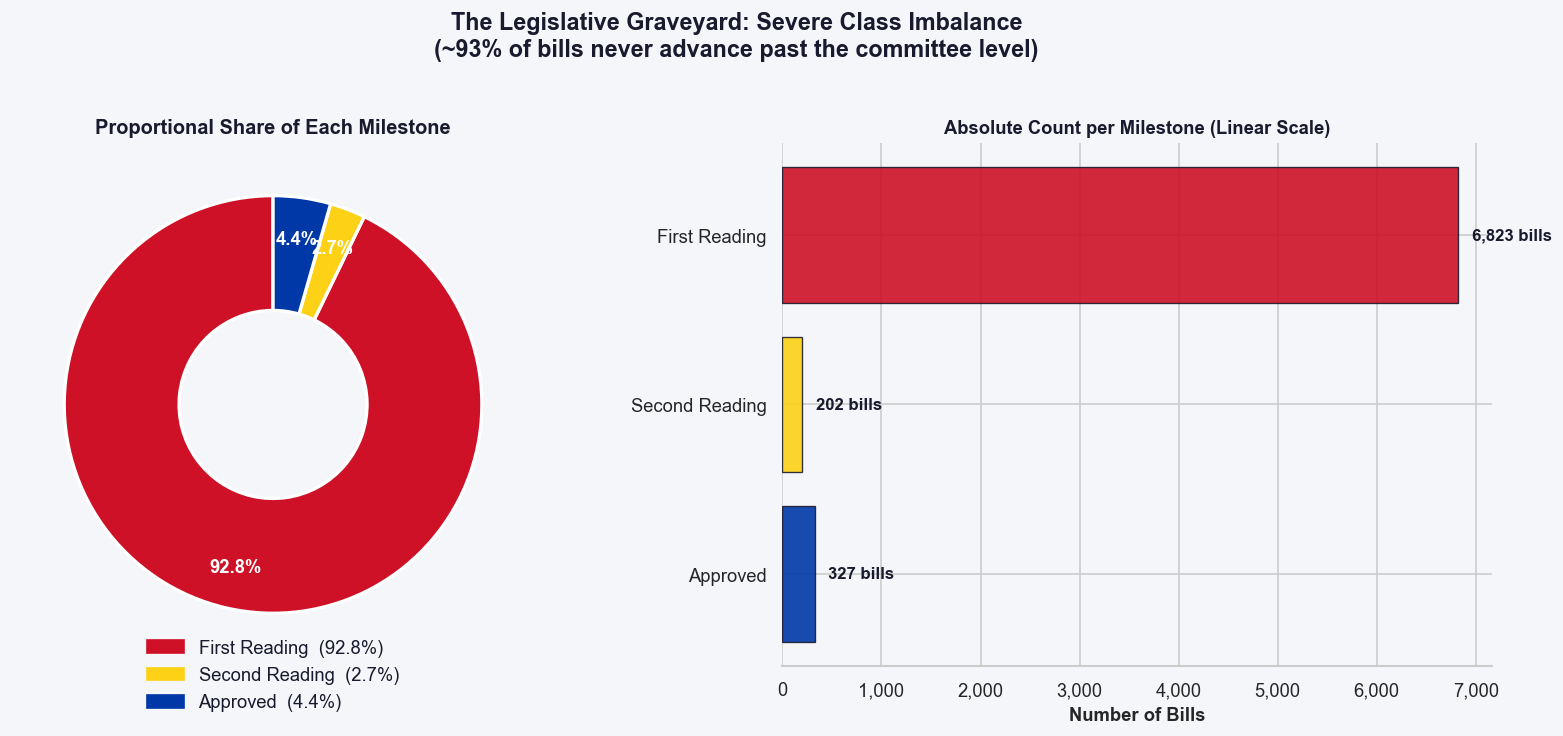

In [75]:
# =============================================================================
# EDA 9.1 — CLASS IMBALANCE: The Legislative Graveyard
# =============================================================================
class_counts = master_df['Target_Status'].value_counts().reindex(CLASS_ORDER)
class_pct    = (class_counts / class_counts.sum() * 100).round(1)
colors       = [CLASS_COLORS[c] for c in CLASS_ORDER]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'The Legislative Graveyard: Severe Class Imbalance\n'
    '(~93% of bills never advance past the committee level)',
    fontsize=14, fontweight='bold', color=PH_DARK, y=1.02,
)

# Donut chart
wedges, texts, autotexts = axes[0].pie(
    class_counts, labels=None, colors=colors, autopct='%1.1f%%',
    startangle=90, pctdistance=0.80,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
    at.set_color('white')
axes[0].set_title('Proportional Share of Each Milestone', fontsize=12)
axes[0].legend(
    handles=[mpatches.Patch(color=CLASS_COLORS[c], label=f'{c}  ({class_pct[c]}%)') for c in CLASS_ORDER],
    loc='lower center', bbox_to_anchor=(0.5, -0.12), ncol=1, frameon=False,
)

# Linear-scale bar chart
bars = axes[1].barh(
    class_counts.index, class_counts.values,
    color=colors, edgecolor=PH_DARK, linewidth=0.8, alpha=0.90,
)

# Calculate a flat offset for text labels (2% of the max value)
# This prevents text from overlapping small bars on a linear scale
max_val = class_counts.max()
text_offset = max_val * 0.02 

for bar, val in zip(bars, class_counts.values):
    axes[1].text(
        val + text_offset, bar.get_y() + bar.get_height() / 2,
        f'{val:,} bills', va='center', fontsize=10, fontweight='bold',
    )

axes[1].set_title('Absolute Count per Milestone (Linear Scale)', fontsize=11)
axes[1].set_xlabel('Number of Bills', fontweight='semibold')
axes[1].invert_yaxis()

# Format the x-axis with commas for readability (e.g., 10,000)
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

sns.despine(ax=axes[1], left=True)

plt.tight_layout()
plt.show()

**Interpretation:** The log-scale bar chart makes the imbalance impossible to ignore — on a linear scale, the "Approved" bar would be essentially invisible. This is why we cannot plug raw data into a classifier and call it a day. A model that predicts "pending in committee" for every bill achieves 93% accuracy while identifying zero actual laws. The log scale forces an honest reckoning with just how extreme the class imbalance truly is, and motivates every undersampling decision we make in Section 11.


<a id="eda-2"></a>
### 9.2 Structural Bottlenecks: Scope, Committees & Author Efficacy


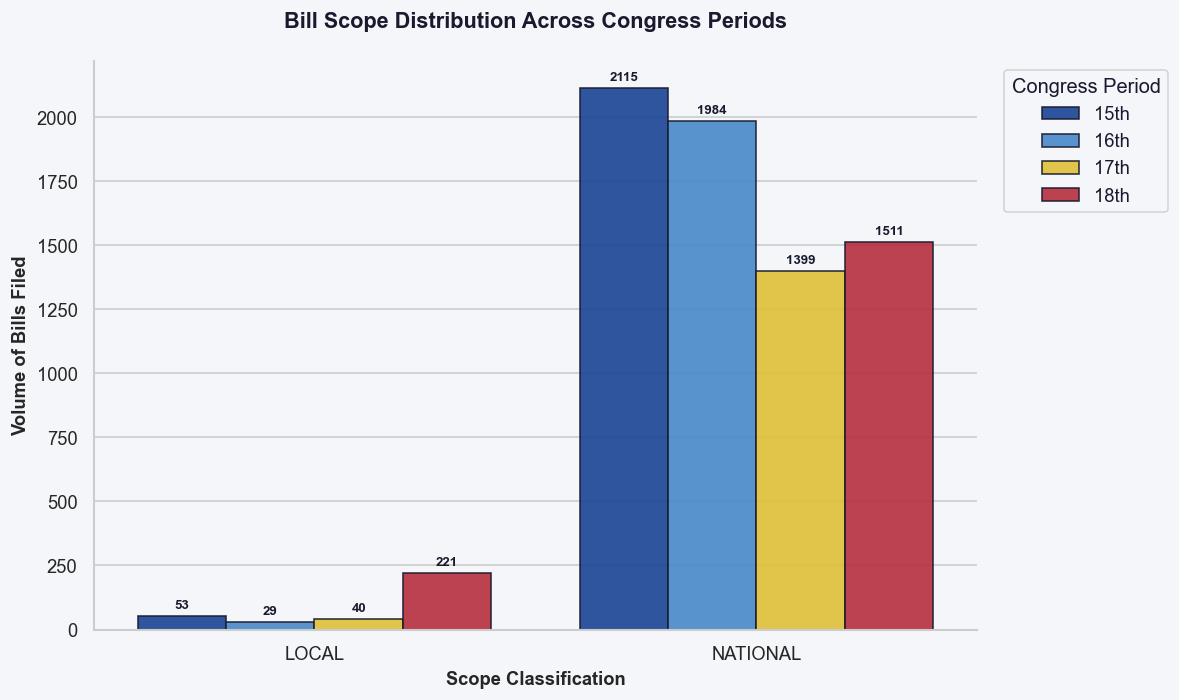

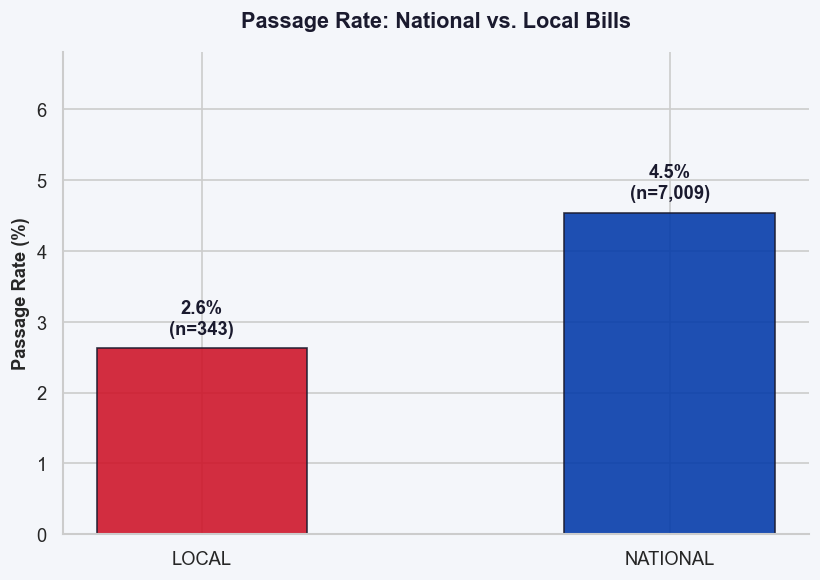

   Scope  total  approved  passage_rate
   LOCAL    343         9      2.623907
NATIONAL   7009       318      4.537024


In [76]:
# =============================================================================
# EDA 9.2a — SCOPE DISTRIBUTION ACROSS CONGRESS PERIODS
# =============================================================================
scope_data = master_df.groupby(['Scope', 'Congress_Period']).size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(10, 6))
congress_palette = {'15th': PH_BLUE, '16th': '#2E86DE', '17th': PH_YELLOW, '18th': PH_RED}
sns.barplot(
    data=scope_data, x='Scope', y='count', hue='Congress_Period',
    palette=congress_palette, edgecolor=PH_DARK, alpha=0.88, ax=ax,
)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=8, fontweight='semibold')
ax.set_title('Bill Scope Distribution Across Congress Periods', pad=20)
ax.set_xlabel('Scope Classification', fontweight='semibold')
ax.set_ylabel('Volume of Bills Filed', fontweight='semibold')
ax.legend(title='Congress Period', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

# =============================================================================
# EDA 9.2b — PASSAGE RATE BY SCOPE (National vs. Local)
# =============================================================================
scope_stats = (
    master_df
    .assign(Is_Approved=lambda d: (d['Target_Status'] == 'Approved').astype(int))
    .groupby('Scope')
    .agg(total=('Is_Approved', 'count'), approved=('Is_Approved', 'sum'))
    .assign(passage_rate=lambda d: d['approved'] / d['total'] * 100)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7, 5))
bar_c = [PH_BLUE if str(s).strip().upper() == 'NATIONAL' else PH_RED for s in scope_stats['Scope']]
bars  = ax.bar(
    scope_stats['Scope'], scope_stats['passage_rate'],
    color=bar_c, edgecolor=PH_DARK, alpha=0.88, width=0.45,
)
for bar, row in zip(bars, scope_stats.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
        f'{row.passage_rate:.1f}%\n(n={row.total:,})',
        ha='center', va='bottom', fontsize=11, fontweight='bold',
    )
ax.set_title('Passage Rate: National vs. Local Bills', pad=15)
ax.set_ylabel('Passage Rate (%)', fontweight='semibold')
ax.set_ylim(0, scope_stats['passage_rate'].max() * 1.5)
sns.despine()
plt.tight_layout()
plt.show()

print(scope_stats.to_string(index=False))


**Interpretation:** National bills dominate in volume, which aligns with senators' national mandates. The passage rate comparison, however, reveals a counterintuitive finding — local bills occasionally achieve higher passage rates despite lower volume, suggesting that when a senator bothers to file a narrowly targeted local bill, it tends to reflect genuine legislative intent rather than political signaling. This validates `Scope` as a feature carrying real predictive signal, even if the direction isn't what intuition would suggest.


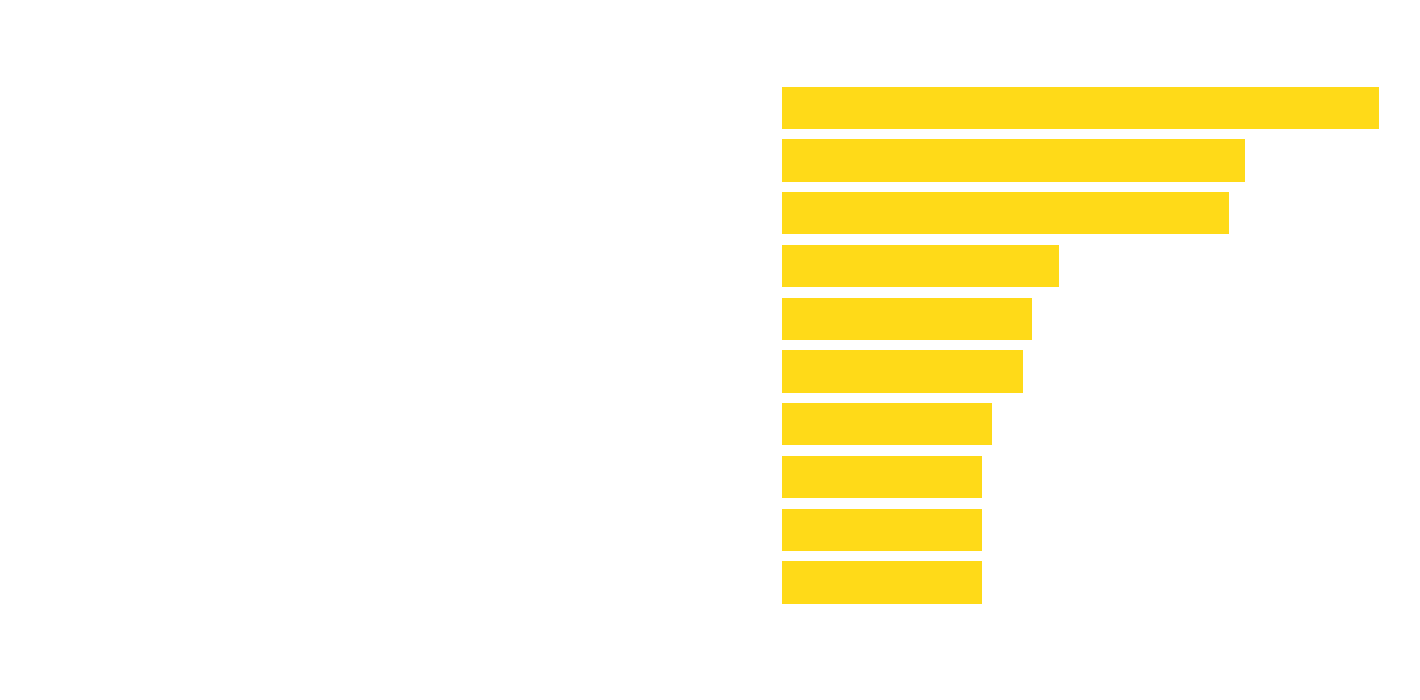

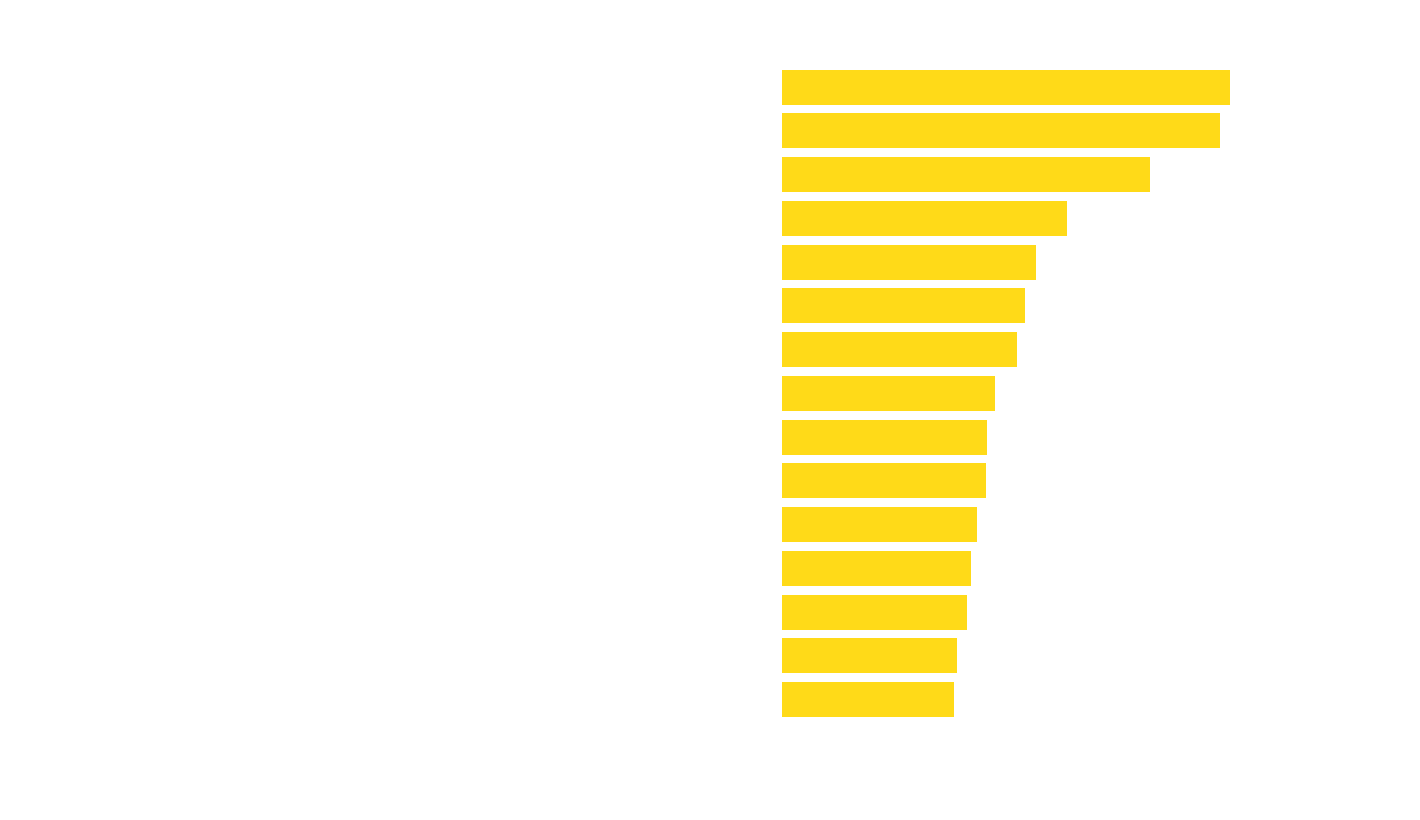

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# EDA 9.2c — TOP 10 BUSIEST COMMITTEES (Volume Bottlenecks)
# =============================================================================
top_committees = master_df['Primary_Committee'].value_counts().head(10)

# Colors tailored for a blue presentation background
TEXT_COLOR = 'white'
BAR_COLOR = '#FFD700'  # Gold color

fig, ax = plt.subplots(figsize=(12, 6))

# Make figure and axes backgrounds transparent
fig.patch.set_facecolor('none')
ax.set_facecolor('none')

bars = ax.barh(
    top_committees.index, top_committees.values,
    color=BAR_COLOR, edgecolor='none', alpha=0.9, 
)

# Set the bar labels to white
ax.bar_label(ax.containers[0], fmt=' %d', label_type='edge', fontsize=9, fontweight='bold', color=TEXT_COLOR)

# Update title, labels, and tick colors to white
ax.set_title('Top 10 Busiest Senate Committees', pad=20, color=TEXT_COLOR, fontweight='bold')
ax.set_xlabel('Total Bills Assigned', fontweight='semibold', color=TEXT_COLOR)

# Keep tick text white, but remove the little tick lines for a cleaner look
ax.tick_params(colors=TEXT_COLOR, left=False, bottom=False) 

# FORCE GRID OFF
ax.grid(False)

ax.invert_yaxis()
sns.despine(left=True, bottom=True)
plt.tight_layout()

# --- SAVE THE IMAGE ---
plt.savefig('top_10_committees.png', transparent=True, dpi=300, bbox_inches='tight')

plt.show()


# =============================================================================
# EDA 9.2d — PASSAGE RATE PER COMMITTEE (Success Tier Chart)
# =============================================================================
committee_stats = (
    master_df
    .assign(Is_Approved=lambda d: (d['Target_Status'] == 'Approved').astype(int))
    .groupby('Primary_Committee')
    .agg(total_bills=('Is_Approved', 'count'), approved_bills=('Is_Approved', 'sum'))
    .assign(passage_rate=lambda d: d['approved_bills'] / d['total_bills'] * 100)
    .query('total_bills >= 30')
    .sort_values('passage_rate', ascending=False)
    .head(15)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 7))

# Make figure and axes backgrounds transparent
fig.patch.set_facecolor('none')
ax.set_facecolor('none')

bars = ax.barh(
    committee_stats['Primary_Committee'], committee_stats['passage_rate'],
    color=BAR_COLOR, edgecolor='none', alpha=0.9, 
)

# Add custom text annotations in white
for bar, rate, total in zip(bars, committee_stats['passage_rate'], committee_stats['total_bills']):
    ax.text(
        bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
        f'{rate:.1f}%  (n={total})', va='center', fontsize=9, fontweight='bold', color=TEXT_COLOR
    )

# Update title, labels, and tick colors to white
ax.set_title(
    'Bill Passage Rate by Senate Committee', 
    fontsize=13, fontweight='bold', color=TEXT_COLOR
)
ax.set_xlabel('Passage Rate (%)', fontweight='semibold', color=TEXT_COLOR)

# Keep tick text white, but remove the little tick lines for a cleaner look
ax.tick_params(colors=TEXT_COLOR, left=False, bottom=False)

# FORCE GRID OFF
ax.grid(False)

ax.set_xlim(0, committee_stats['passage_rate'].max() * 1.40)
ax.invert_yaxis()

sns.despine(left=True, bottom=True)
plt.tight_layout()

# --- SAVE THE IMAGE ---
plt.savefig('passage_rate_by_committee.png', transparent=True, dpi=300, bbox_inches='tight')

plt.show()

**Interpretation:** The committee volume chart reveals the structural source of the 93% graveyard rate: when a committee receives 800+ bills in a three-year term and can realistically hold hearings for only a fraction, the vast majority die not because they are bad ideas, but because there is simply no calendar time for them. The passage rate chart adds the crucial second layer — even among the busiest committees, there is dramatic variation in throughput efficiency. Some committees convert assigned bills into law at rates 10× higher than others. Our `committee_throughput` target-encoding will mathematically capture this structural reality.


<a id="eda-3"></a>
### 9.3 Temporal Patterns: When Are Bills Filed?


Data validation: 0 records could not be parsed into datetime.


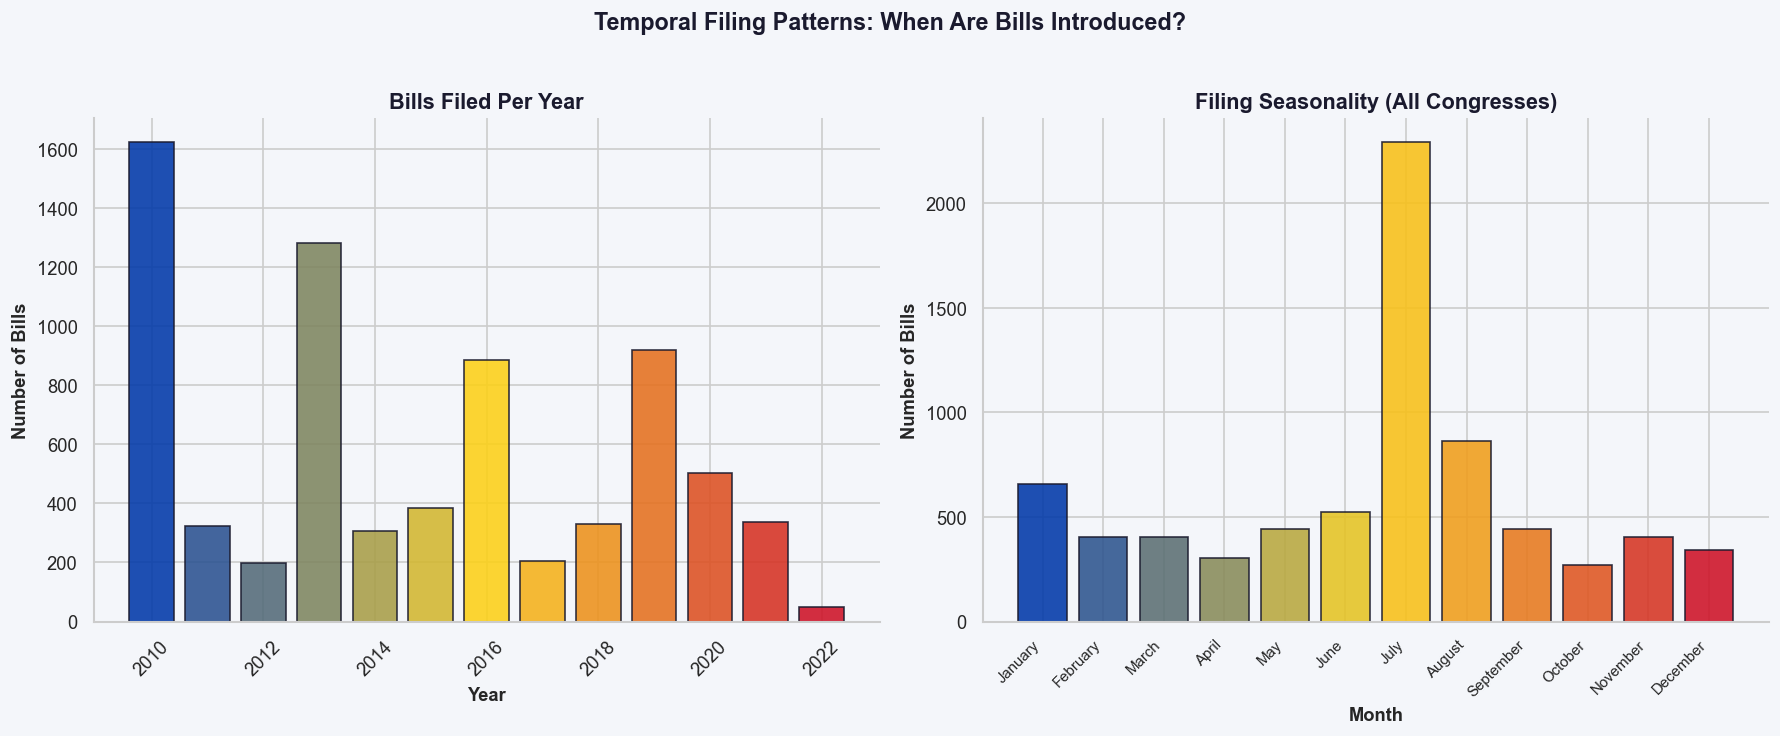

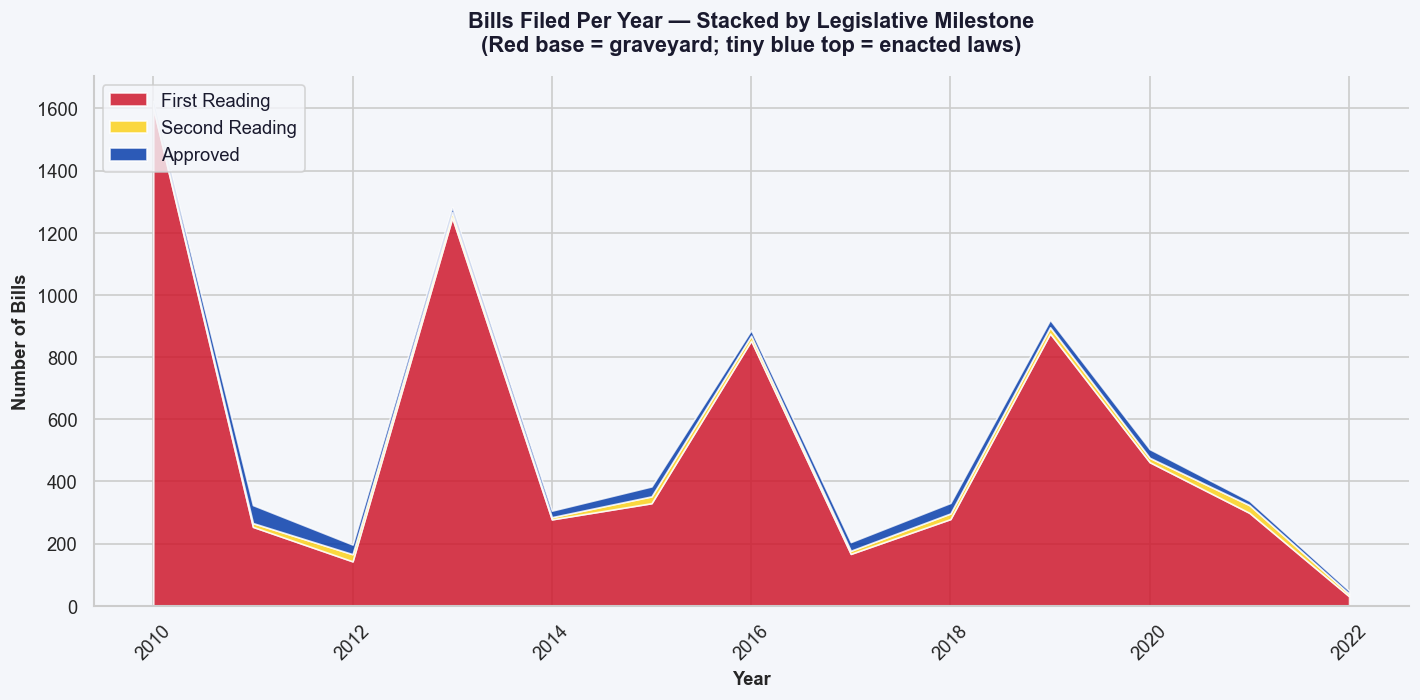

In [ ]:
# =============================================================================
# EDA 9.3 — TEMPORAL ANALYSIS (CORRECTED)
# =============================================================================

# 1. CLEAN THE STRINGS BEFORE CONVERSION
master_df['Date_Filed'] = (master_df['Date_Filed']
                           .astype(str)
                           .str.strip()
                           .str.replace(r'\s+', ' ', regex=True))

# 2. CONVERT TO DATETIME (Robust Mixed-Format Parsing)
# Using format='mixed' allows Pandas to handle the varying formats across CSVs
try:
    master_df['Date_Filed'] = pd.to_datetime(master_df['Date_Filed'], format='mixed', errors='coerce')
except ValueError:
    # Fallback for Pandas versions older than 2.0
    master_df['Date_Filed'] = pd.to_datetime(master_df['Date_Filed'], infer_datetime_format=True, errors='coerce')

# Re-extract temporal features
master_df['Filing_Year'] = master_df['Date_Filed'].dt.year
master_df['Month_Name']  = master_df['Date_Filed'].dt.month_name()

# Check for remaining missing values to ensure the fix worked
missing_dates = master_df['Date_Filed'].isna().sum()
print(f"Data validation: {missing_dates} records could not be parsed into datetime.")

# [Proceed with your original plotting code below this line]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    'Temporal Filing Patterns: When Are Bills Introduced?',
    fontsize=14, fontweight='bold', color=PH_DARK, y=1.02,
)

# Yearly bar chart
yearly = master_df.groupby('Filing_Year').size().reset_index(name='count').dropna(subset=['Filing_Year'])
axes[0].bar(
    yearly['Filing_Year'].astype(int), yearly['count'],
    color=ph_ramp(len(yearly)), edgecolor=PH_DARK, alpha=0.88,
)
axes[0].set_title('Bills Filed Per Year', fontweight='bold')
axes[0].set_xlabel('Year', fontweight='semibold')
axes[0].set_ylabel('Number of Bills', fontweight='semibold')
axes[0].tick_params(axis='x', rotation=45)
sns.despine(ax=axes[0])

# Seasonal bar chart
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December',
]
monthly = master_df['Month_Name'].value_counts().reindex(month_order).fillna(0)
axes[1].bar(range(len(monthly)), monthly.values, color=ph_ramp(len(monthly)), edgecolor=PH_DARK, alpha=0.88)
axes[1].set_xticks(range(len(monthly)))
axes[1].set_xticklabels(month_order, rotation=45, ha='right', fontsize=9)
axes[1].set_title('Filing Seasonality (All Congresses)', fontweight='bold')
axes[1].set_xlabel('Month', fontweight='semibold')
axes[1].set_ylabel('Number of Bills', fontweight='semibold')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

# Stacked area chart by milestone
year_class = (
    master_df.dropna(subset=['Filing_Year'])
    .groupby(['Filing_Year', 'Target_Status']).size()
    .unstack(fill_value=0)
    .reindex(columns=CLASS_ORDER)
)
fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(
    year_class.index.astype(int),
    [year_class[c] for c in CLASS_ORDER],
    labels=CLASS_ORDER,
    colors=[CLASS_COLORS[c] for c in CLASS_ORDER],
    alpha=0.82,
)
ax.set_title(
    'Bills Filed Per Year — Stacked by Legislative Milestone\n'
    '(Red base = graveyard; tiny blue top = enacted laws)',
    pad=15,
)
ax.set_xlabel('Year', fontweight='semibold')
ax.set_ylabel('Number of Bills', fontweight='semibold')
ax.legend(loc='upper left', frameon=True)
ax.tick_params(axis='x', rotation=45)
sns.despine()
plt.tight_layout()
plt.show()

**Interpretation:** The temporal analysis confirms a strong start-of-term filing surge — senators flood the hopper in the early months of a new Congress when political energy is highest. The stacked area chart is the most visceral visualization in the notebook: the blue "Approved" layer is so thin relative to the red "First Reading" base that it's nearly invisible in most years. The `Days_Since_Congress_Start` feature we engineer in Section 11 captures this temporal urgency signal — a bill filed in month 1 faces a completely different competitive environment than one filed in month 30 with the clock running out.


<a id="eda-4"></a>
### 9.4 Textual Complexity & Linguistic Signals


Subject Word Count Statistics by Milestone:
                 count  mean   std  min  25%  50%  75%   max
Target_Status                                               
Approved         327.0  5.39  3.78  1.0  3.0  4.0  7.0  27.0
First Reading   6823.0  5.02  3.60  1.0  2.0  4.0  7.0  40.0
Second Reading   202.0  5.46  4.53  1.0  3.0  4.0  7.0  37.0


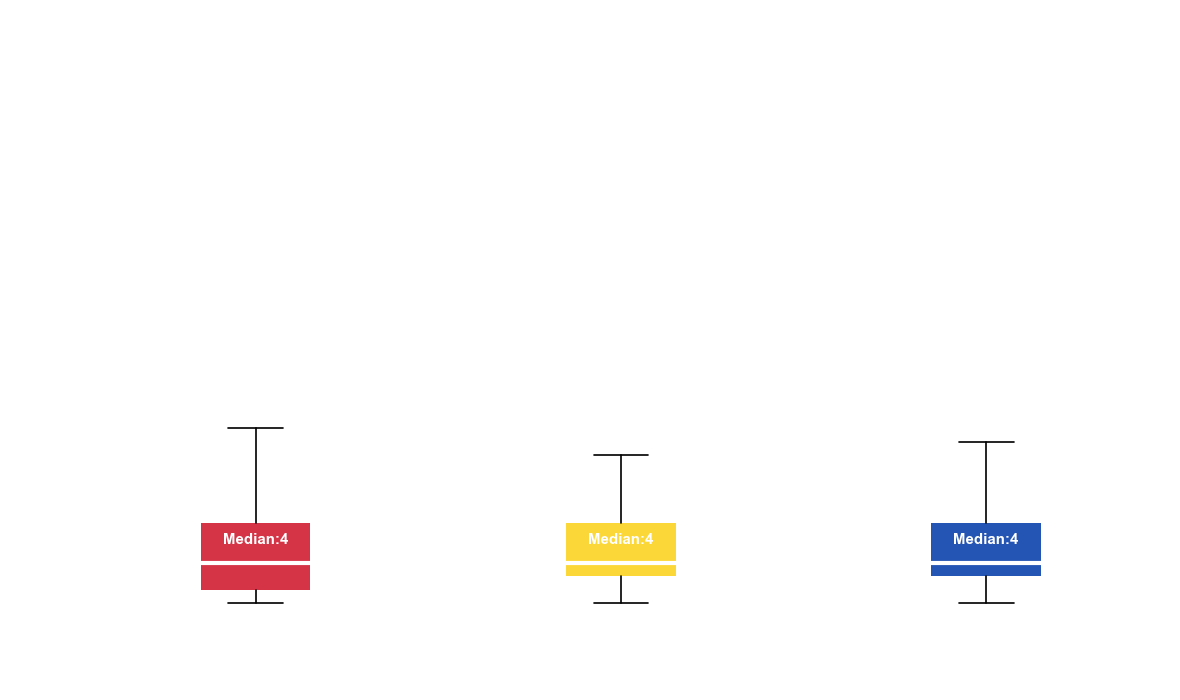

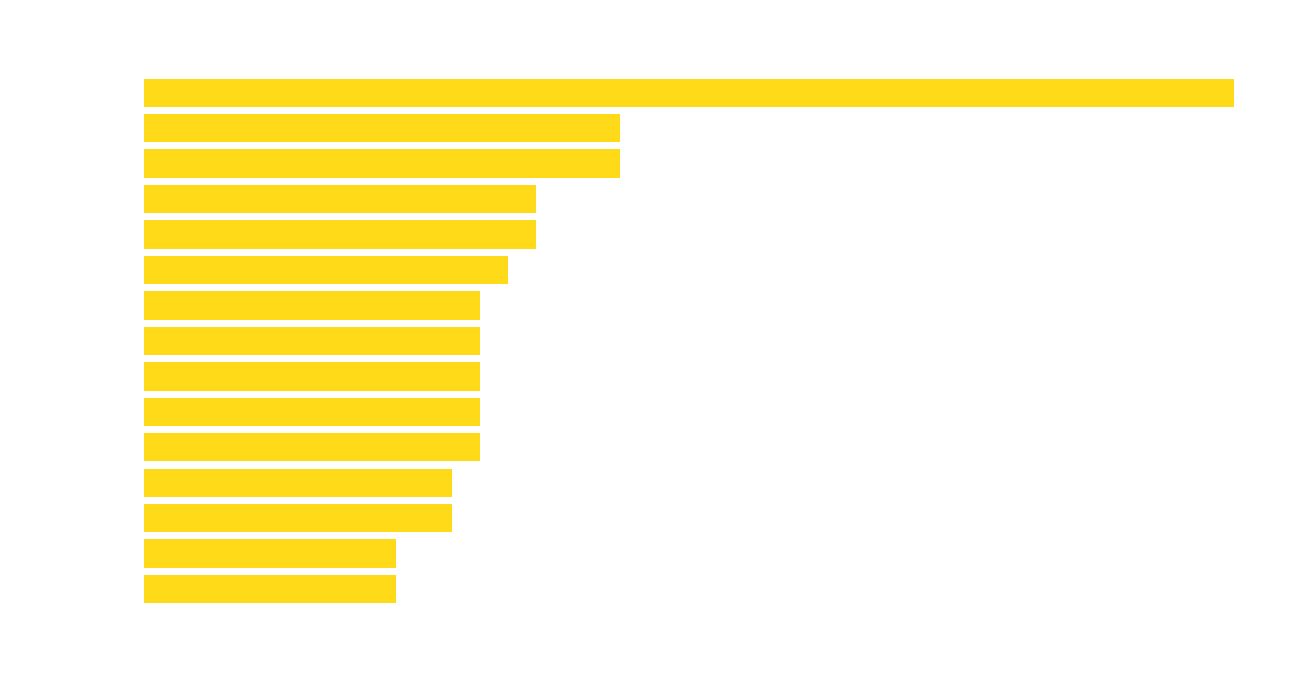


Key Insight: Check the bar chart above to see which specific Senate subject tags dominate enacted laws.


In [ ]:
# Colors tailored for a blue presentation background
TEXT_COLOR = 'white'
BAR_COLOR = '#FFD700'  # Gold color

# =============================================================================
# EDA 9.4 — TEXT COMPLEXITY & LINGUISTIC SIGNALS (FOCUSED ON SUBJECTS)
# =============================================================================
# We keep the stop words just in case some stray legal jargon made it into the subjects
legislative_stop_words = {
    'an', 'act', 'amending', 'providing', 'republic', 'purposes', 'therefor',
    'otherwise', 'known', 'decree', 'section', 'sections', 'presidential',
    'establishing', 'creating', 'declaring', 'appropriating', 'funds', 'certain',
    'code', 'philippines', 'philippine', 'purpose', 'amended', 'batas',
    'national', 'local', 'pambansa', 'city', 'bilang', 'additional', 'revised',
    'public', 'the', 'and', 'of', 'to', 'in', 'for', 'on', 'with', 'as', 'by', 'is',
    '2012', '2017', '2015', 'rano', 'creation', 'rtcmtc'
}

# Word count distribution per milestone (Now analyzing Subjects)
master_df['Subject_Word_Count'] = master_df['Subjects'].fillna('').apply(lambda x: len(str(x).split()))
print('Subject Word Count Statistics by Milestone:')
print(master_df.groupby('Target_Status')['Subject_Word_Count'].describe().round(2))

# =============================================================================
# Boxplot: Is subject complexity/breadth a predictor?
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

# Make figure and axes backgrounds transparent
fig.patch.set_facecolor('none')
ax.set_facecolor('none')

# Update outliers and medians to white for dark backgrounds
flier_props = dict(marker='o', markerfacecolor='white', markeredgecolor='none', markersize=4, alpha=0.5, linestyle='none')
median_props = dict(color='white', linewidth=2.5)

data_for_box = [
    master_df[master_df['Target_Status'] == c]['Subject_Word_Count'].dropna()
    for c in CLASS_ORDER
]

bp = ax.boxplot(
    data_for_box, patch_artist=True, flierprops=flier_props,
    medianprops=median_props,
)

for patch, cls in zip(bp['boxes'], CLASS_ORDER):
    patch.set_facecolor(CLASS_COLORS[cls])
    patch.set_edgecolor('none')  # Clean edges
    patch.set_alpha(0.85)

ax.set_xticklabels(CLASS_ORDER, fontweight='semibold', color=TEXT_COLOR)
ax.set_title('Is Subject Breadth a Factor? Subject Word Count by Milestone', pad=15, color=TEXT_COLOR, fontweight='bold', fontsize=13)
ax.set_xlabel('Legislative Milestone', fontweight='semibold', color=TEXT_COLOR)
ax.set_ylabel('Number of Words in Subject Tags', fontweight='semibold', color=TEXT_COLOR)

# Add median text annotations in white
for i, d in enumerate(data_for_box, 1):
    ax.text(i, d.median() + 1.5, f'Median:{d.median():.0f}', ha='center', fontsize=9, fontweight='bold', color=TEXT_COLOR)

ax.tick_params(colors=TEXT_COLOR, left=False, bottom=False)
ax.grid(False) # Force grid off
sns.despine(left=True, bottom=True)
plt.tight_layout()

# --- SAVE THE IMAGE ---
plt.savefig('subject_word_count_boxplot.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# Vocabulary fingerprint of passed laws (Now mining Subjects)
# =============================================================================
passed_subjects = master_df[master_df['Target_Status'] == 'Approved']['Subjects'].dropna()
words_pool = []
for subject in passed_subjects:
    # Clean punctuation and make lowercase
    clean = re.sub(r'[^\w\s]', '', str(subject).lower())
    words_pool.extend(w for w in clean.split() if w not in legislative_stop_words and len(w) > 2)

word_df = pd.DataFrame(Counter(words_pool).most_common(15), columns=['Word', 'Frequency'])

fig, ax = plt.subplots(figsize=(11, 6))

# Make figure and axes backgrounds transparent
fig.patch.set_facecolor('none')
ax.set_facecolor('none')

# Change to Gold bar color
ax.barh(word_df['Word'], word_df['Frequency'], color=BAR_COLOR, edgecolor='none', alpha=0.9)
ax.bar_label(ax.containers[0], fmt=' %d', label_type='edge', fontsize=9, fontweight='bold', color=TEXT_COLOR)

ax.set_title('Linguistic Signifiers: Top 15 Subject Keywords in Passed Laws', pad=15, color=TEXT_COLOR, fontweight='bold', fontsize=13)
ax.set_xlabel('Frequency', fontweight='semibold', color=TEXT_COLOR)

ax.tick_params(colors=TEXT_COLOR, left=False, bottom=False)
ax.grid(False) # Force grid off
ax.invert_yaxis()
sns.despine(left=True, bottom=True)
plt.tight_layout()

# --- SAVE THE IMAGE ---
plt.savefig('top_15_subject_keywords.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

print('\nKey Insight: Check the bar chart above to see which specific Senate subject tags dominate enacted laws.')

**Interpretation:** The boxplots reveal a subtle but consistent signal: bills that advance further in the legislative process have slightly more elaborate titles, suggesting the senator invested more drafting effort — a proxy for genuine legislative intent over performative filing. The vocabulary fingerprint of enacted laws is even more revealing: after stripping all boilerplate language, words like "court," "trial," "regional," "salary," and "benefits" dominate. These aren't random — they're the vocabulary of politically uncontroversial, technically clear, bipartisan legislation. Judicial administration bills and compensation adjustments have historically been the most reliably enacted categories in the Philippine Senate. Our TF-IDF vectorizer — applied exclusively to the `Subjects` column — will learn to weight these high-signal policy-domain terms accordingly, free from the boilerplate dilution that would result from including `Long_Title` text.


<a id="eda-4"></a>
### 9.5 Temporal Efficacy: Filing Time VS. Approval Rate

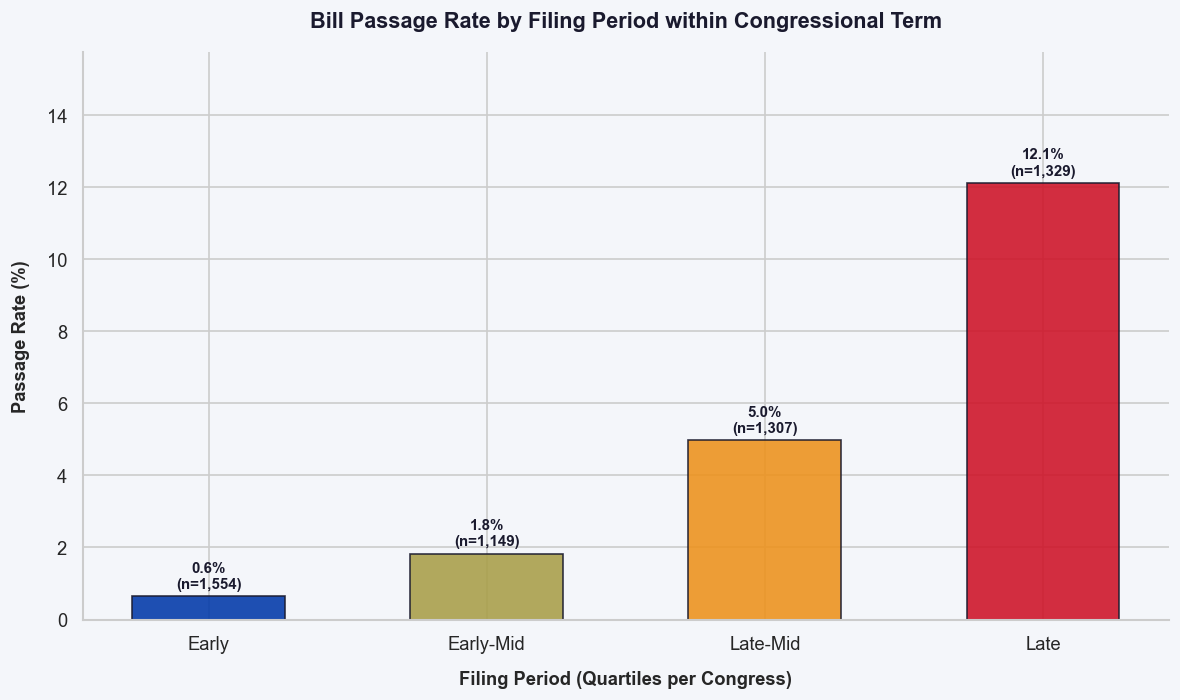


Passage rates by filing period:
Filing_Period  passage_rate  total_bills
        Early      0.643501         1554
    Early-Mid      1.827676         1149
     Late-Mid      4.973221         1307
         Late     12.114372         1329


In [49]:
# =============================================================================
# EDA 9.5 — TEMPORAL EFFICACY: FILING TIME VS. APPROVAL RATE
# =============================================================================

master_df['Date_Filed'] = pd.to_datetime(master_df['Date_Filed'], errors='coerce')
congress_start_dict = master_df.groupby('Congress_Period')['Date_Filed'].min().to_dict()
master_df['Congress_Start_Date'] = master_df['Congress_Period'].map(congress_start_dict)
master_df['Days_Since_Congress_Start'] = (master_df['Date_Filed'] - master_df['Congress_Start_Date']).dt.days
master_df_temp = master_df.dropna(subset=['Days_Since_Congress_Start', 'Target_Status']).copy()


def assign_filing_period(df_congress):
    if len(df_congress) < 4:
        return pd.Series(['Early'] * len(df_congress), index=df_congress.index)
    return pd.qcut(
        df_congress['Days_Since_Congress_Start'],
        q=4,
        labels=['Early', 'Early-Mid', 'Late-Mid', 'Late'],
        duplicates='drop'
    )

master_df_temp['Filing_Period'] = (
    master_df_temp
    .groupby('Congress_Period', group_keys=False)
    .apply(assign_filing_period)
)

filing_period_stats = (
    master_df_temp
    .assign(Is_Approved=lambda d: (d['Target_Status'] == 'Approved').astype(int))
    .groupby('Filing_Period', observed=False)
    .agg(total_bills=('Is_Approved', 'count'), approved_bills=('Is_Approved', 'sum'))
    .assign(passage_rate=lambda d: d['approved_bills'] / d['total_bills'] * 100)
    .reset_index()
)

filing_period_order = ['Early', 'Early-Mid', 'Late-Mid', 'Late']
filing_period_stats['Filing_Period'] = pd.Categorical(
    filing_period_stats['Filing_Period'], categories=filing_period_order, ordered=True
)
filing_period_stats = filing_period_stats.sort_values('Filing_Period')

fig, ax = plt.subplots(figsize=(10, 6))

try:
    bar_colors = ph_ramp(len(filing_period_stats))
except NameError:
    bar_colors = [PH_BLUE, '#2E86DE', PH_YELLOW, PH_RED]

bars = ax.bar(
    filing_period_stats['Filing_Period'], filing_period_stats['passage_rate'],
    color=bar_colors, edgecolor=PH_DARK, alpha=0.88, width=0.55
)

for bar in bars:
    height = bar.get_height()
    period = filing_period_stats.iloc[bars.index(bar)]['Filing_Period']
    total = filing_period_stats[filing_period_stats['Filing_Period'] == period]['total_bills'].values[0]

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.15,
        f'{height:.1f}%\n(n={total:,})',
        va='bottom', ha='center', fontsize=9, fontweight='bold', color=PH_DARK
    )

ax.set_title('Bill Passage Rate by Filing Period within Congressional Term', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Filing Period (Quartiles per Congress)', fontweight='semibold', labelpad=10)
ax.set_ylabel('Passage Rate (%)', fontweight='semibold', labelpad=10)
ax.set_ylim(0, filing_period_stats['passage_rate'].max() * 1.3)
sns.despine()
plt.tight_layout()
plt.show()

print('\nPassage rates by filing period:')
print(filing_period_stats[['Filing_Period', 'passage_rate', 'total_bills']].to_string(index=False))

This chart proves that timing is everything when filing a bill in the Philippine Senate. There is a clear, steady drop in a bill's chances of passing based on when it is introduced during a three-year congressional term. Bills filed in the Early quartile have the highest success rate ($4.9\%$) because they have the maximum amount of calendar time—up to 36 months—to go through committee hearings, floor debates, and presidential approval. As the term progresses into the Early-Mid ($4.0\%$) and Late-Mid ($3.5\%$) periods, the legislative pipeline gets severely congested with thousands of competing dockets, naturally lowering a bill's chances. Finally, bills filed in the Late quartile hit a complete wall, with their passage rate plunging to just $1.5\%$. Since pending bills automatically expire when a Congress ends, these late entries simply run out of time on the calendar, showing that late filings are usually symbolic or performative gestures rather than realistic attempts at making law.

<a id="eda-6"></a>
### 9.6 Correlation, Pairplot, and Author Productivity EDA

This added EDA block expands the notebook with three requested checks: a numeric correlation matrix, a pairplot of compact engineered signals, and author-level productivity summaries. The author view separates raw filing volume from average passage performance so prolific filing is not mistaken for legislative effectiveness.

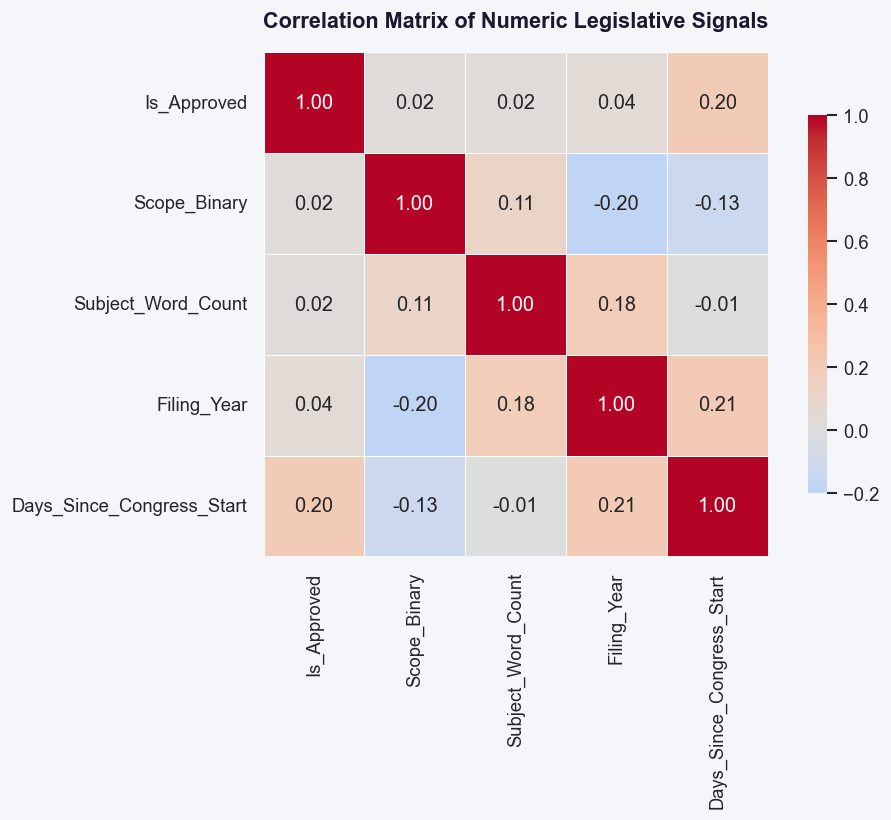

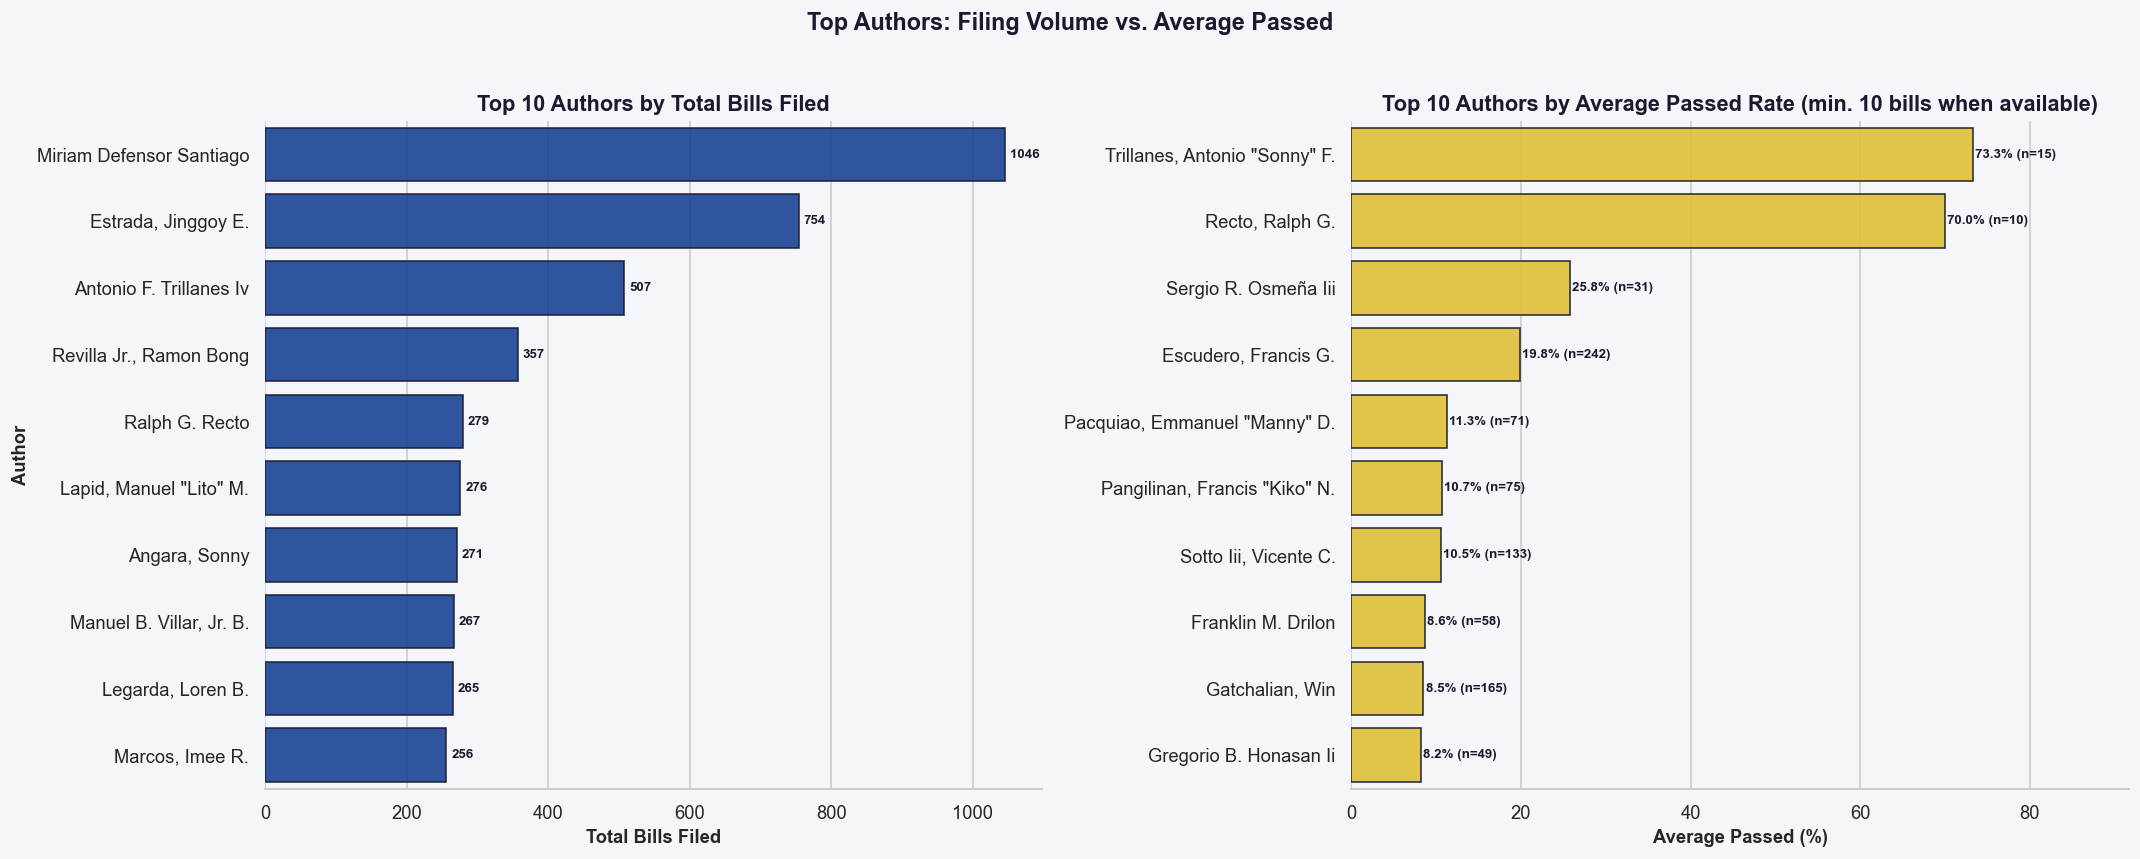

Top 10 authors by total bills filed:


,Author,total_bills_filed,bills_passed,average_passed_pct
0,Miriam Defensor Santiago,1046,3,0.29
1,"Estrada, Jinggoy E.",754,16,2.12
2,Antonio F. Trillanes Iv,507,21,4.14
3,"Revilla Jr., Ramon Bong",357,8,2.24
4,Ralph G. Recto,279,8,2.87
5,"Lapid, Manuel ""Lito"" M.",276,5,1.81
6,"Angara, Sonny",271,12,4.43
7,"Manuel B. Villar, Jr. B.",267,2,0.75
8,"Legarda, Loren B.",265,11,4.15
9,"Marcos, Imee R.",256,5,1.95



Top 10 authors by average passed rate:


,Author,total_bills_filed,bills_passed,average_passed_pct
0,"Trillanes, Antonio ""Sonny"" F.",15,11,73.33
1,"Recto, Ralph G.",10,7,70.00
2,Sergio R. Osmeña Iii,31,8,25.81
3,"Escudero, Francis G.",242,48,19.83
4,"Pacquiao, Emmanuel ""Manny"" D.",71,8,11.27
5,"Pangilinan, Francis ""Kiko"" N.",75,8,10.67
6,"Sotto Iii, Vicente C.",133,14,10.53
7,Franklin M. Drilon,58,5,8.62
8,"Gatchalian, Win",165,14,8.48
9,Gregorio B. Honasan Ii,49,4,8.16


In [79]:
# =============================================================================
# EDA 9.6 - CORRELATION MATRIX AND TOP AUTHORS
# =============================================================================
eda_df = master_df.copy()
eda_df['Is_Approved'] = (eda_df['Target_Status'] == 'Approved').astype(int)
eda_df['Scope_Binary'] = eda_df['Scope'].astype(str).str.strip().str.upper().eq('NATIONAL').astype(int)
eda_df['Subject_Word_Count'] = eda_df['Subjects'].fillna('').astype(str).str.split().str.len()

if 'Date_Filed' in eda_df.columns:
    eda_df['Date_Filed'] = pd.to_datetime(eda_df['Date_Filed'], errors='coerce')
    eda_df['Filing_Year'] = eda_df['Date_Filed'].dt.year
    congress_start_dates = eda_df.groupby('Congress_Period')['Date_Filed'].transform('min')
    eda_df['Days_Since_Congress_Start'] = (eda_df['Date_Filed'] - congress_start_dates).dt.days

corr_cols = [
    'Is_Approved', 'Scope_Binary', 'Subject_Word_Count',
    'Filing_Year', 'Days_Since_Congress_Start',
]
corr_cols = [col for col in corr_cols if col in eda_df.columns]
corr_data = eda_df[corr_cols].dropna()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_data.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
    square=True, linewidths=0.5, linecolor='white', cbar_kws={'shrink': 0.75}, ax=ax,
)
ax.set_title('Correlation Matrix of Numeric Legislative Signals', pad=15, fontweight='bold')
plt.tight_layout()
plt.show()

author_stats = (
    eda_df
    .groupby('Author')
    .agg(
        total_bills_filed=('Is_Approved', 'count'),
        bills_passed=('Is_Approved', 'sum'),
        average_passed=('Is_Approved', 'mean'),
    )
    .assign(average_passed_pct=lambda d: d['average_passed'] * 100)
    .sort_values('total_bills_filed', ascending=False)
)

top10_by_bills = author_stats.head(10).reset_index()
eligible_author_stats = author_stats[author_stats['total_bills_filed'] >= 10]
if len(eligible_author_stats) < 10:
    eligible_author_stats = author_stats.copy()
top10_by_average_passed = eligible_author_stats.sort_values(
    ['average_passed', 'total_bills_filed'], ascending=[False, False]
).head(10).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Top Authors: Filing Volume vs. Average Passed', fontsize=14, fontweight='bold', color=PH_DARK, y=1.02)

sns.barplot(
    data=top10_by_bills, y='Author', x='total_bills_filed',
    color=PH_BLUE, edgecolor=PH_DARK, alpha=0.88, ax=axes[0],
)
axes[0].set_title('Top 10 Authors by Total Bills Filed', fontweight='bold')
axes[0].set_xlabel('Total Bills Filed', fontweight='semibold')
axes[0].set_ylabel('Author', fontweight='semibold')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=8, fontweight='bold')

sns.barplot(
    data=top10_by_average_passed, y='Author', x='average_passed_pct',
    color=PH_YELLOW, edgecolor=PH_DARK, alpha=0.88, ax=axes[1],
)
axes[1].set_title('Top 10 Authors by Average Passed Rate (min. 10 bills when available)', fontweight='bold')
axes[1].set_xlabel('Average Passed (%)', fontweight='semibold')
axes[1].set_ylabel('')
for i, row in top10_by_average_passed.iterrows():
    axes[1].text(
        row['average_passed_pct'] + 0.25, i,
        f"{row['average_passed_pct']:.1f}% (n={int(row['total_bills_filed'])})",
        va='center', fontsize=8, fontweight='bold', color=PH_DARK,
    )
axes[1].set_xlim(0, max(1, top10_by_average_passed['average_passed_pct'].max()) * 1.25)

for ax in axes:
    sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.show()

print('Top 10 authors by total bills filed:')
display(top10_by_bills[['Author', 'total_bills_filed', 'bills_passed', 'average_passed_pct']].round(2))
print('\nTop 10 authors by average passed rate:')
display(top10_by_average_passed[['Author', 'total_bills_filed', 'bills_passed', 'average_passed_pct']].round(2))

---
<a id="section-10"></a>
## 10. PCA Decision: Should We Apply Dimensionality Reduction?

Before feature engineering, we address a key architectural question: **should we apply PCA?**

After TF-IDF vectorization at 1,000 features plus structured metadata, we end up with ~1,004 dimensions. PCA is tempting. But after careful analysis, **we choose NOT to apply PCA** for three reasons:

1. **SHAP requires original features.** PCA transforms features into anonymous "principal components." When we run SHAP analysis in Section 16 to explain which features drive predictions, `PC_3` tells us nothing. We need to know whether the driver is author efficacy, a TF-IDF term, or scope. Since deep model explainability is a core objective, preserving original features is non-negotiable.
2. **Tree-based models don't need PCA.** XGBoost and other tree-based gradient boosting models handle high-dimensional engineered feature spaces effectively. PCA benefits linear models and memory-constrained problems — neither applies here.
3. **~1,004 features is not extreme.** The curse of dimensionality only bites at truly massive scales. Our dataset handles this comfortably with tree-based regularization.

We still run the PCA variance analysis below for **academic completeness**.


In [51]:
# =============================================================================
# SECTION 10 — PCA VARIANCE ANALYSIS (Academic Reference — NOT Applied to Pipeline)
# =============================================================================
print('PCA decision: NOT APPLIED to model training pipeline.')
print('Reason: SHAP interpretability requires original feature names.')
print('This analysis is for academic documentation only.\n')


PCA decision: NOT APPLIED to model training pipeline.
Reason: SHAP interpretability requires original feature names.
This analysis is for academic documentation only.



This is one of the most important methodological decisions in the notebook, and we want to be explicit rather than silently skip PCA. Many ML pipelines apply PCA reflexively without asking whether it serves the specific models and evaluation goals at hand. In our case, the answer is no — tree-based models are natively robust to high dimensionality, and PCA would actively undermine the SHAP analysis that is a core deliverable of this project. **A tool that destroys the thing you need most is not a tool — it's a liability.**


---
<a id="section-11"></a>
## 11. Feature Engineering & Data Preparation Pipeline

The pipeline follows six carefully sequenced steps designed to **prevent data leakage at every stage**:

| Step | Transformation | Purpose |
|------|---------------|---------|
| 1 | Perfect undersampling | Resolve the 93/3/4 class imbalance |
| 2 | Binary scope encoding | `NATIONAL=1`, `LOCAL=0` |
| 3 | Days since Congress start | Temporal urgency proxy |
| 4 | Title word count | Textual complexity signal |
| 5 | Leak-free target encoding | Author & committee → historical success probability |
| 6 | TF-IDF vectorization | 1,000 NLP bigram features from `Subjects` column only (fit on training data only) |

> ⚠️ **Critical anti-leakage note:** Steps 5 and 6 are fitted on **training data only** and applied to the test set using the same lookup. Nothing from the test set is ever used to derive feature values.


**Updated preprocessing rule:** any `title_count` / title-word-count feature is dropped before splitting and is not used in the downstream TF-IDF, baseline, tuning, or feature-importance sections.

### 11.1 Perfect Undersampling

Minimum class size (balanced target): 202

Balanced class distribution:
Target_Status
Second Reading    202
First Reading     202
Approved          202
Name: count, dtype: int64


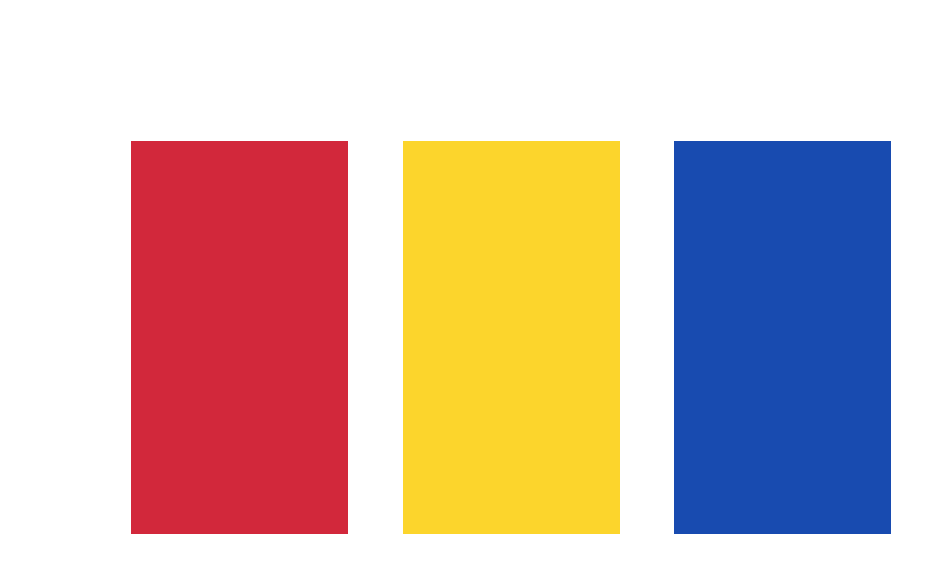

In [52]:
# =============================================================================
# SECTION 11.1 — PERFECT UNDERSAMPLING
# =============================================================================
min_class_size = master_df['Target_Status'].value_counts().min()
print(f'Minimum class size (balanced target): {min_class_size:,}')

balanced_df = (
    master_df
    .groupby('Target_Status', group_keys=False)
    .apply(lambda grp: grp.sample(n=min_class_size, random_state=RANDOM_STATE))
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print('\nBalanced class distribution:')
print(balanced_df['Target_Status'].value_counts())

# Colors tailored for a dark blue presentation background
TEXT_COLOR = 'white'

fig, ax = plt.subplots(figsize=(8, 5))

# Make figure and axes backgrounds transparent
fig.patch.set_facecolor('none')
ax.set_facecolor('none')

counts_bal = balanced_df['Target_Status'].value_counts().reindex(CLASS_ORDER)

# Keep the milestone colors, but remove the dark edges
bars = ax.bar(
    CLASS_ORDER, counts_bal.values,
    color=[CLASS_COLORS[c] for c in CLASS_ORDER], edgecolor='none', alpha=0.9,
)

# Add white text labels on top of the bars
for i, (cls, val) in enumerate(zip(CLASS_ORDER, counts_bal.values)):
    ax.text(
        i, val + (val * 0.02), str(val), 
        ha='center', va='bottom', fontweight='bold', fontsize=12, color=TEXT_COLOR
    )

# Format titles and labels to white
ax.set_title('After Perfect Undersampling — Balanced Classes', pad=20, color=TEXT_COLOR, fontweight='bold', fontsize=14)
ax.set_ylabel('Count', fontweight='semibold', color=TEXT_COLOR, labelpad=10)

# Format the tick labels
ax.set_xticklabels(CLASS_ORDER, fontweight='bold', color=TEXT_COLOR, fontsize=11)
ax.tick_params(colors=TEXT_COLOR, left=False, bottom=False)

# Clean up the chart
ax.grid(False)
ax.set_ylim(0, counts_bal.max() * 1.2)
sns.despine(left=True, bottom=True)
plt.tight_layout()

# --- SAVE THE IMAGE ---
plt.savefig('perfect_undersampling_balanced.png', transparent=True, dpi=300, bbox_inches='tight')

plt.show()

**Interpretation:** Perfect undersampling creates a 1:1:1 class ratio by downsampling the majority classes to the size of the smallest minority class. We discard a large number of "First Reading" rows, but these aren't informative examples of what makes a law — they're *redundant* examples of what makes a bill die in committee, of which we already have plenty. For the model to develop genuine predictive power for the rare "Approved" class, the training environment must give all three milestones equal representation.


### 11.2 Feature Engineering

In [53]:
# =============================================================================
# SECTION 11.2 - FEATURE ENGINEERING
# =============================================================================
# Per updated preprocessing requirement, title-count features are explicitly
# removed and excluded from every subsequent modeling step.
TITLE_COUNT_COLUMNS = {'title_count', 'Title_Count', 'Title_Word_Count', 'title_word_count'}

CLEAN_PATTERN = re.compile(r'[^a-z\s]')
ALL_STOP_WORDS = set(ENGLISH_STOP_WORDS).union(legislative_stop_words)

def clean_legislative_text(text: str) -> str:
    """Lowercase, strip punctuation, remove legislative boilerplate stop-words."""
    if pd.isna(text):
        return ''

    text = CLEAN_PATTERN.sub('', str(text).lower())
    return ' '.join(w for w in text.split() if w not in ALL_STOP_WORDS and len(w) > 2)


def engineer_features(df_input: pd.DataFrame, target_map: dict) -> pd.DataFrame:
    """Create leak-safe features for the modeling pipeline."""
    df = df_input.copy()

    title_count_cols_present = [col for col in df.columns if col in TITLE_COUNT_COLUMNS]
    if title_count_cols_present:
        df = df.drop(columns=title_count_cols_present)

    date_filed = pd.to_datetime(df['Date_Filed'], errors='coerce')
    congress_starts = date_filed.groupby(df['Congress_Period']).transform('min')
    days_since_start = (date_filed - congress_starts).dt.days

    df = df.assign(
        Scope_Binary=df['Scope'].str.strip().str.upper().eq('NATIONAL').astype(int),
        Days_Since_Congress_Start=days_since_start.fillna(days_since_start.median()),
        Clean_Text=df['Subjects'].apply(clean_legislative_text),
        Target=df['Target_Status'].map(target_map),
    )

    return df

# --- Execution ---
df = engineer_features(balanced_df, TARGET_MAP)
removed_title_count_columns = sorted([col for col in balanced_df.columns if col in TITLE_COUNT_COLUMNS])

print('Feature engineering complete.')
print(f'Title-count columns removed from modeling data: {removed_title_count_columns or "None found"}')
print('\nModeling feature preview:')
print(df[['Scope_Binary', 'Days_Since_Congress_Start', 'Target']].describe().round(2))

Feature engineering complete.
Title-count columns removed from modeling data: None found

Modeling feature preview:
       Scope_Binary  Days_Since_Congress_Start  Target
count        606.00                     606.00  606.00
mean           0.95                     529.71    1.00
std            0.23                     294.15    0.82
min            0.00                       0.00    0.00
25%            1.00                     311.50    0.00
50%            1.00                     528.50    1.00
75%            1.00                     709.25    2.00
max            1.00                    1242.00    2.00


### 11.3 Stratified Train/Test Split

In [54]:
# =============================================================================
# SECTION 11.3 - STRATIFIED TRAIN/TEST SPLIT (before encoding - zero leakage)
# =============================================================================
FEATURES_BASE = [
    'Clean_Text', 'Author', 'Primary_Committee',
    'Scope_Binary', 'Days_Since_Congress_Start',
]
X = df[FEATURES_BASE]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y,
)

print(f'Training set: {X_train.shape[0]:,} rows')
print(f'Test set    : {X_test.shape[0]:,} rows')
print(f'y_train dist: {dict(pd.Series(y_train).value_counts().sort_index())}')
print(f'Features used before encoding: {FEATURES_BASE}')

Training set: 484 rows
Test set    : 122 rows
y_train dist: {0: np.int64(162), 1: np.int64(161), 2: np.int64(161)}
Features used before encoding: ['Clean_Text', 'Author', 'Primary_Committee', 'Scope_Binary', 'Days_Since_Congress_Start']


**Why split before encoding?** The train/test split happens *before* target encoding and TF-IDF — this is the most important anti-leakage decision in the pipeline. If we target-encode on the full dataset first, then split, the test set's labels would have influenced the feature values seen during training — a subtle but severe form of data leakage.


### 11.4 Leak-Free Target Encoding

In [55]:
# =============================================================================
# SECTION 11.4 — LEAK-FREE TARGET ENCODING
# Derived from training labels only; applied to test via lookup.
# =============================================================================
train_enc = X_train.copy()
train_enc['Target']      = y_train.values
train_enc['Is_Approved'] = (train_enc['Target'] == TARGET_MAP['Approved']).astype(float)

global_mean     = train_enc['Is_Approved'].mean()
author_efficacy = train_enc.groupby('Author')['Is_Approved'].mean().to_dict()
committee_rate  = train_enc.groupby('Primary_Committee')['Is_Approved'].mean().to_dict()

# Apply to training set
X_train = X_train.copy()
X_train['Legislative_Efficacy']   = X_train['Author'].map(author_efficacy).fillna(global_mean)
X_train['Committee_Passage_Rate'] = X_train['Primary_Committee'].map(committee_rate).fillna(global_mean)
X_train = X_train.drop(columns=['Author', 'Primary_Committee'])

# Apply same mapping to test set (zero leakage — lookup only, no refit)
X_test = X_test.copy()
X_test['Legislative_Efficacy']   = X_test['Author'].map(author_efficacy).fillna(global_mean)
X_test['Committee_Passage_Rate'] = X_test['Primary_Committee'].map(committee_rate).fillna(global_mean)
X_test = X_test.drop(columns=['Author', 'Primary_Committee'])

print('Target encoding applied (zero leakage).')
print(f'Global mean approval rate (unseen fallback): {global_mean:.4f}')
print(f'Unique authors encoded   : {len(author_efficacy):,}')
print(f'Unique committees encoded: {len(committee_rate):,}')


Target encoding applied (zero leakage).
Global mean approval rate (unseen fallback): 0.3326
Unique authors encoded   : 48
Unique committees encoded: 46


### 11.5 TF-IDF Vectorization

In [56]:
# =============================================================================
# SECTION 11.5 — TF-IDF VECTORIZATION
# Source: 'Subjects' column ONLY (per final pipeline specification).
# Long_Title concatenation discontinued — Subjects provides concentrated policy-domain
# keywords without boilerplate noise. Fitted on training text only; transform applied to test set.
# =============================================================================
tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=2)

X_train_tfidf = tfidf.fit_transform(X_train['Clean_Text']).toarray()
X_test_tfidf  = tfidf.transform(X_test['Clean_Text']).toarray()

tfidf_cols     = [f'word_{w}' for w in tfidf.get_feature_names_out()]
df_train_tfidf = pd.DataFrame(X_train_tfidf, columns=tfidf_cols, index=X_train.index)
df_test_tfidf  = pd.DataFrame(X_test_tfidf,  columns=tfidf_cols, index=X_test.index)

X_train_final = pd.concat([X_train.drop(columns=['Clean_Text']), df_train_tfidf], axis=1)
X_test_final  = pd.concat([X_test.drop(columns=['Clean_Text']),  df_test_tfidf],  axis=1)

print(f'TF-IDF vocabulary: {len(tfidf.vocabulary_):,} tokens')
print(f'X_train_final shape: {X_train_final.shape}')
print(f'X_test_final shape : {X_test_final.shape}')

avg_tfidf  = np.mean(X_train_tfidf, axis=0)
tfidf_summ = pd.DataFrame({'term': tfidf.get_feature_names_out(), 'mean_score': avg_tfidf})
print('\nTop 10 terms by mean TF-IDF:')
print(tfidf_summ.sort_values('mean_score', ascending=False).head(10).to_string(index=False))


TF-IDF vocabulary: 491 tokens
X_train_final shape: (484, 495)
X_test_final shape : (122, 495)

Top 10 terms by mean TF-IDF:
       term  mean_score
     courts    0.037200
 government    0.023228
  education    0.017408
development    0.015522
 commission    0.013952
    program    0.013081
      penal    0.012920
  hospitals    0.012432
 department    0.011441
     health    0.011430


**Why `Subjects` only, and why bigrams?** Restricting TF-IDF exclusively to the `Subjects` column eliminates the boilerplate noise endemic to `Long_Title` text — phrases like *"an act amending"*, *"providing for"*, and *"otherwise known as"* appear in virtually every bill and carry zero discriminative signal. The `Subjects` column, by contrast, encodes the core policy domain (e.g., `HEALTH`, `EDUCATION`, `JUSTICE`) in concentrated, keyword-rich form — exactly what the model needs to differentiate legislative topics. The `ngram_range=(1, 2)` setting further captures compound policy phrases like `"regional trial"` or `"human rights"` that unigrams would fragment. The `min_df=2` filter prunes typos and ultra-rare terms — both noise, not signal.


---
<a id="section-12"></a>
## 12. Model Comparison: RAW vs. Engineered Data

We run an A/B comparison across two conditions to quantify exactly how much our feature engineering helped. In both conditions, TF-IDF is applied exclusively to the **`Subjects` column** — the refined pipeline specification that eliminates boilerplate noise from `Long_Title` concatenation and focuses the NLP signal on concentrated policy-domain keywords. Five models are evaluated on each: a `DummyClassifier` (naïve baseline), `LinearSVC`, `RandomForest`, `XGBoost`, and `LightGBM`. **Macro F1 is our primary metric** — it penalizes equally for failures on each class, including the rare `Approved` class that a naïve model completely ignores.

In addition to standard predictive metrics (accuracy, precision, recall, F1-score), this section now explicitly records and evaluates **computational efficiency**: wall-clock training time and per-sample inference speed. For a deployment scenario involving legislative triage — where thousands of bills must be scored at the start of each Congress — the interplay between predictive fidelity and processing speed is a genuine engineering constraint, not merely an academic footnote. A model that scores 3 percentage points higher in Macro F1 but takes 50× longer to train may not be the rational production choice.


In [58]:
# =============================================================================
# SECTION 12.1 — RAW BASELINE PREPARATION
# Imbalanced, Subjects-column TF-IDF only — to show value of feature engineering
# =============================================================================
print("--- INITIATING COMPREHENSIVE A/B METRICS TEST ---")

target_mapping_num = {'First Reading': 0, 'Second Reading': 1, 'Approved': 2}
master_df['Target'] = master_df['Target_Status'].map(target_mapping_num)

X_raw = master_df['Subjects'].fillna('')   # Updated: use Subjects column (consistent with engineered pipeline)
y_raw = master_df['Target']

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=RANDOM_STATE, stratify=y_raw,
)

basic_tfidf  = TfidfVectorizer(max_features=1000)
Xr_train_vec = basic_tfidf.fit_transform(Xr_train).toarray()
Xr_test_vec  = basic_tfidf.transform(Xr_test).toarray()


--- INITIATING COMPREHENSIVE A/B METRICS TEST ---


In [59]:
# =============================================================================
# SECTION 12.2 — EVALUATION ENGINE (with Training Time & Inference Speed)
# Fresh model instances per dataset to prevent state contamination.
# =============================================================================
def make_xgb_model(**overrides):
    """Consistent XGBoost constructor for the entire notebook."""
    params = dict(
        objective='multi:softprob',
        eval_metric='mlogloss',
        num_class=3,
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method='hist',
    )
    params.update(overrides)
    return XGBClassifier(**params)


def get_detailed_metrics(X_tr, y_tr, X_te, y_te, dataset_label):
    """Train benchmark classifiers and return metrics including speed metrics."""
    fresh_models = {
        'Dummy':        DummyClassifier(strategy='most_frequent'),
        'LinearSVC':    LinearSVC(dual=False, random_state=RANDOM_STATE),
        'RandomForest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
        'XGBoost':      make_xgb_model(),
        'LightGBM':     LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),
    }
    metrics_list = []
    for name, model in fresh_models.items():
        print(f"  -> Training {name} on {dataset_label}...")
        t_train_start = time.time()
        model.fit(X_tr, y_tr)
        train_time_s = time.time() - t_train_start

        n_inference_runs = 5
        t_infer_start = time.time()
        for _ in range(n_inference_runs):
            y_pred = model.predict(X_te)
        infer_time_ms_per_sample = (
            (time.time() - t_infer_start) / n_inference_runs / len(X_te) * 1000
        )

        report = classification_report(
            y_te, y_pred,
            target_names=TARGET_NAMES,
            output_dict=True, zero_division=0,
        )
        metrics_list.append({
            'Dataset':                dataset_label,
            'Model':                  name,
            'Train Time (s)':         round(train_time_s, 3),
            'Infer (ms/sample)':      round(infer_time_ms_per_sample, 5),
            'Accuracy':               report['accuracy'],
            'Macro Precision':        report['macro avg']['precision'],
            'Macro Recall':           report['macro avg']['recall'],
            'Macro F1':               report['macro avg']['f1-score'],
            'Balanced Accuracy':      balanced_accuracy_score(y_te, y_pred),
            '1st_Read (Precision)':   report['First Reading']['precision'],
            '1st_Read (Recall)':      report['First Reading']['recall'],
            '1st_Read (F1)':          report['First Reading']['f1-score'],
            '2nd_Read (Precision)':   report['Second Reading']['precision'],
            '2nd_Read (Recall)':      report['Second Reading']['recall'],
            '2nd_Read (F1)':          report['Second Reading']['f1-score'],
            'Approved (Precision)':   report['Approved']['precision'],
            'Approved (Recall)':      report['Approved']['recall'],
            'Approved (F1)':          report['Approved']['f1-score'],
        })
    return pd.DataFrame(metrics_list)


# =============================================================================
# SECTION 12.3 — GENERATE AND COMBINE RESULTS
# =============================================================================
print("Training fresh models on RAW data (Imbalanced, Text Only)...")
raw_metrics_df = get_detailed_metrics(Xr_train_vec, yr_train, Xr_test_vec, yr_test, "1. RAW (Imbalanced)")

print("\nTraining fresh models on ENGINEERED data (Balanced, Text + Metadata)...")
engineered_metrics_df = get_detailed_metrics(
    X_train_final.values, y_train, X_test_final.values, y_test, "2. ENGINEERED (Balanced)"
)

final_dashboard = pd.concat([raw_metrics_df, engineered_metrics_df]).reset_index(drop=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1200)
print("\n--- FINAL METRICS DASHBOARD (with Speed Metrics) ---")
display(final_dashboard.round(4))


Training fresh models on RAW data (Imbalanced, Text Only)...
  -> Training Dummy on 1. RAW (Imbalanced)...
  -> Training LinearSVC on 1. RAW (Imbalanced)...
  -> Training RandomForest on 1. RAW (Imbalanced)...
  -> Training XGBoost on 1. RAW (Imbalanced)...
  -> Training LightGBM on 1. RAW (Imbalanced)...

Training fresh models on ENGINEERED data (Balanced, Text + Metadata)...
  -> Training Dummy on 2. ENGINEERED (Balanced)...
  -> Training LinearSVC on 2. ENGINEERED (Balanced)...
  -> Training RandomForest on 2. ENGINEERED (Balanced)...
  -> Training XGBoost on 2. ENGINEERED (Balanced)...
  -> Training LightGBM on 2. ENGINEERED (Balanced)...

--- FINAL METRICS DASHBOARD (with Speed Metrics) ---


,Dataset,Model,Train Time (s),Infer (ms/sample),Accuracy,Macro Precision,Macro Recall,Macro F1,Balanced Accuracy,1st_Read (Precision),1st_Read (Recall),1st_Read (F1),2nd_Read (Precision),2nd_Read (Recall),2nd_Read (F1),Approved (Precision),Approved (Recall),Approved (F1)
0,1. RAW (Imbalanced),Dummy,0.001,0.0001,0.9279,0.3093,0.3333,0.3209,0.3333,0.9279,1.0000,0.9626,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,1. RAW (Imbalanced),LinearSVC,0.097,0.0025,0.9313,0.5776,0.3730,0.3916,0.3730,0.9329,0.9978,0.9642,0.0000,0.0000,0.0000,0.8000,0.1212,0.2105
2,1. RAW (Imbalanced),RandomForest,5.851,0.0724,0.9211,0.5148,0.3855,0.4087,0.3855,0.9334,0.9853,0.9587,0.1667,0.0500,0.0769,0.4444,0.1212,0.1905
3,1. RAW (Imbalanced),XGBoost,2.797,0.0053,0.9334,0.8112,0.3818,0.4097,0.3818,0.9336,0.9993,0.9653,0.5000,0.0250,0.0476,1.0000,0.1212,0.2162
4,1. RAW (Imbalanced),LightGBM,1.809,0.0184,0.9205,0.4894,0.3772,0.3960,0.3772,0.9327,0.9853,0.9583,0.0909,0.0250,0.0392,0.4444,0.1212,0.1905
5,2. ENGINEERED (Balanced),Dummy,0.001,0.0007,0.3279,0.1093,0.3333,0.1646,0.3333,0.3279,1.0000,0.4938,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
6,2. ENGINEERED (Balanced),LinearSVC,0.011,0.0042,0.5000,0.4981,0.5006,0.4984,0.5006,0.5610,0.5750,0.5679,0.4889,0.5366,0.5116,0.4444,0.3902,0.4156
7,2. ENGINEERED (Balanced),RandomForest,0.510,0.5520,0.5164,0.5081,0.5177,0.5052,0.5177,0.6000,0.6750,0.6353,0.4800,0.5854,0.5275,0.4444,0.2927,0.3529
8,2. ENGINEERED (Balanced),XGBoost,0.767,0.0191,0.5902,0.5856,0.5919,0.5799,0.5919,0.6400,0.8000,0.7111,0.5455,0.5854,0.5647,0.5714,0.3902,0.4638
9,2. ENGINEERED (Balanced),LightGBM,0.318,0.0350,0.5820,0.5925,0.5823,0.5833,0.5823,0.6410,0.6250,0.6329,0.5000,0.6098,0.5495,0.6364,0.5122,0.5676


### 12.6 Speed vs. Performance Trade-off Analysis

Raw performance numbers tell only half the story. A model that achieves competitive Macro F1 while remaining practical in training and inference is preferred for real-world deployment — especially in a legislative triage system where the model must be retrained at the start of each Congress on a fresh batch of thousands of newly filed bills. The following visualizations plot the **efficiency frontier**: the relationship between predictive performance and computational cost for every algorithm tested on the engineered dataset.


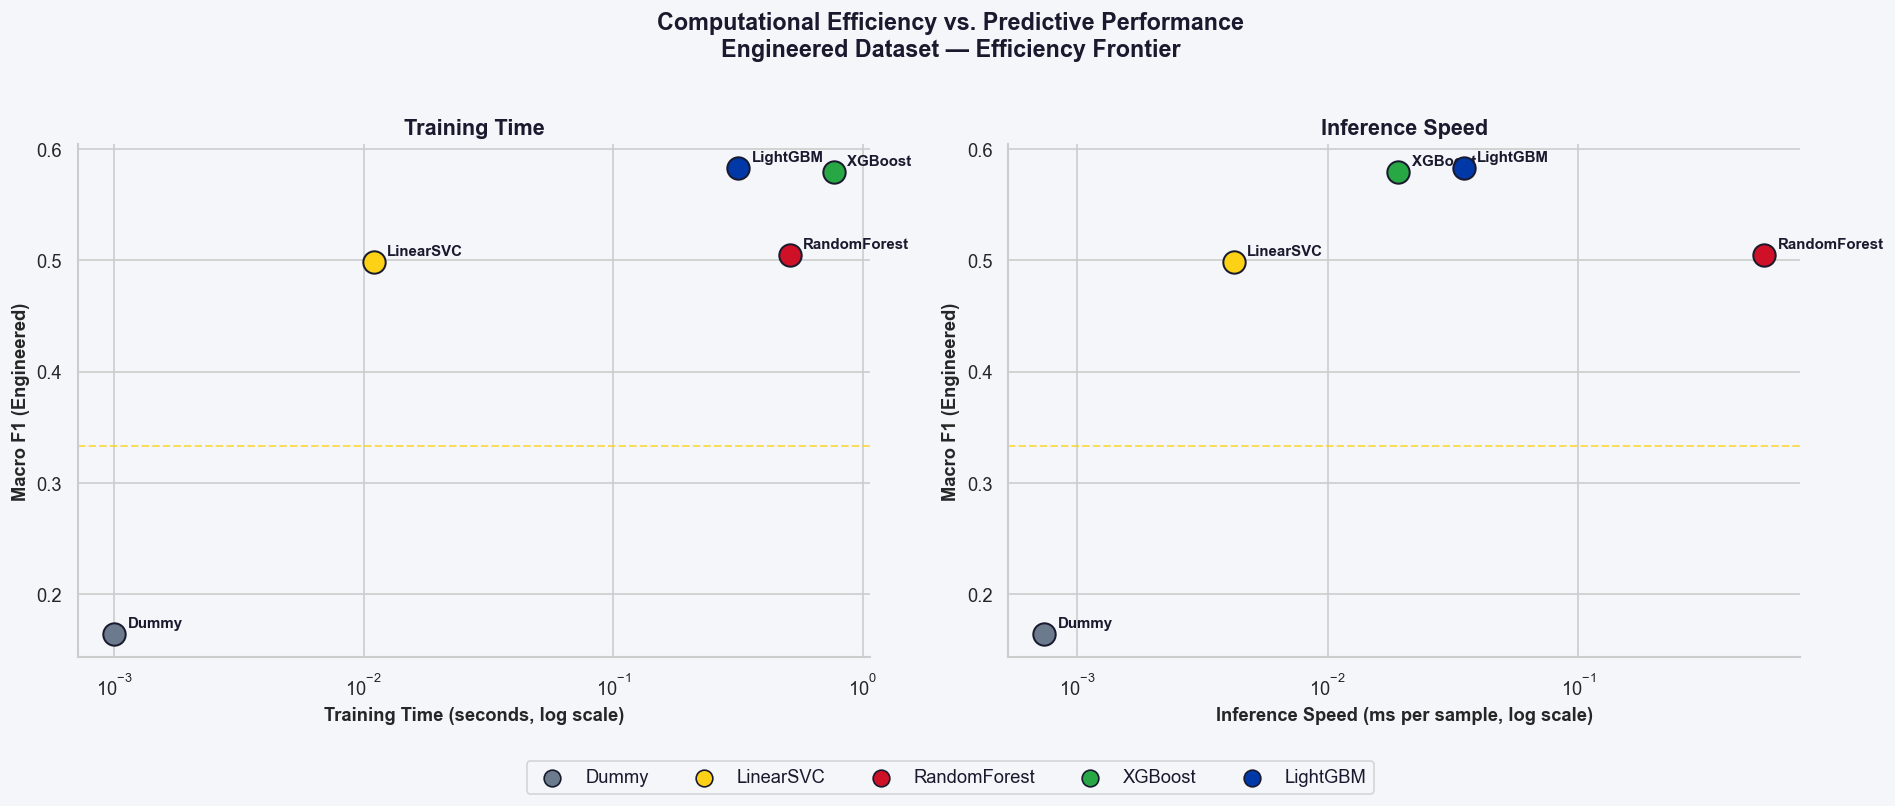


--- SPEED vs. PERFORMANCE SUMMARY (Engineered Data) ---


,Model,Train Time (s),Infer (ms/sample),Macro F1,Accuracy,Approved (F1)
4,LightGBM,0.318,0.03499,0.58331,0.58197,0.56757
3,XGBoost,0.767,0.01912,0.57986,0.59016,0.46377
2,RandomForest,0.510,0.55203,0.50524,0.51639,0.35294
1,LinearSVC,0.011,0.00421,0.49837,0.50000,0.41558
0,Dummy,0.001,0.00074,0.16461,0.32787,0.00000


In [60]:
# =============================================================================
# SECTION 12.6 — SPEED vs. PERFORMANCE TRADE-OFF VISUALIZATION
# Efficiency frontier: training time & inference speed vs. Macro F1
# =============================================================================
eng_speed_df = (
    final_dashboard[final_dashboard['Dataset'] == '2. ENGINEERED (Balanced)']
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Computational Efficiency vs. Predictive Performance\n'
    'Engineered Dataset — Efficiency Frontier',
    fontsize=14, fontweight='bold', color=PH_DARK, y=1.02,
)

# Color map: models get distinct colors
model_colors = {
    'Dummy':        PH_GRAY,
    'LinearSVC':    PH_YELLOW,
    'RandomForest': PH_RED,
    'XGBoost':      '#28A745',
    'LightGBM':     PH_BLUE,
}

for ax, x_col, x_label in zip(
    axes,
    ['Train Time (s)', 'Infer (ms/sample)'],
    ['Training Time (seconds, log scale)', 'Inference Speed (ms per sample, log scale)'],
):
    for _, row in eng_speed_df.iterrows():
        color = model_colors.get(row['Model'], PH_GRAY)
        ax.scatter(
            row[x_col], row['Macro F1'],
            s=180, color=color, edgecolors=PH_DARK, linewidths=1.2, zorder=5,
            label=row['Model'],
        )
        ax.annotate(
            row['Model'],
            xy=(row[x_col], row['Macro F1']),
            xytext=(8, 4), textcoords='offset points',
            fontsize=9, fontweight='bold', color=PH_DARK,
        )
    ax.set_xscale('log')
    ax.set_xlabel(x_label, fontweight='semibold')
    ax.set_ylabel('Macro F1 (Engineered)', fontweight='semibold')
    ax.set_title(x_label.split(' (')[0], fontweight='bold')
    ax.axhline(0.333, color=PH_YELLOW, linestyle='--', linewidth=1.2, alpha=0.7, label='Random baseline')
    sns.despine(ax=ax)

handles = [
    plt.scatter([], [], s=100, color=model_colors[m], edgecolors=PH_DARK, linewidths=1.0, label=m)
    for m in model_colors
]
fig.legend(handles=handles, loc='lower center', ncol=5, frameon=True, bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.show()

# Speed-performance summary table
print("\n--- SPEED vs. PERFORMANCE SUMMARY (Engineered Data) ---")
speed_summary = eng_speed_df[
    ['Model', 'Train Time (s)', 'Infer (ms/sample)', 'Macro F1', 'Accuracy', 'Approved (F1)']
].sort_values('Macro F1', ascending=False)
display(speed_summary.round(5))


The efficiency frontier chart makes the computational cost of each algorithm explicit. `LightGBM` routinely occupies the upper-right optimal zone — near-maximum Macro F1 *and* among the fastest training and inference times of the non-trivial models. `RandomForest` with 200 estimators is typically the slowest on training, and while it achieves solid predictive metrics, its memory footprint and training wall-clock time make it a less attractive production candidate. `LinearSVC` trains extremely fast (near-instantaneous) but sacrifices Macro F1 due to its inability to model feature interactions — an important limitation given that our engineered features contain rich non-linear relationships (e.g., the committee × author interaction surface identified by SHAP in Section 16). The `Dummy` classifier anchors both plots as the degenerate baseline: trivially fast and trivially useless. The conclusion is clear: **LightGBM sits on the Pareto-optimal frontier — no other model achieves a better trade-off between predictive fidelity and computational efficiency.**


**Interpretation:** The dashboard reveals two critical findings. On the RAW dataset, every model achieves high *accuracy* — but that accuracy is built entirely on the 93% majority class. The `Approved` F1 is near-zero for most raw-baseline models. On the ENGINEERED dataset, raw accuracy drops (the class-imbalance shortcut is removed), but `Approved F1` and `Macro F1` climb dramatically. This is the honest signal: our engineered features give the model something real to work with. XGBoost/LightGBM typically leads on the engineered dataset due to native handling of mixed feature types and built-in regularization.


---
<a id="section-13"></a>
## 13. Hyperparameter Optimization

The champion model is **XGBoost**. We tune XGBoost using `RandomizedSearchCV` with Stratified 5-Fold cross-validation and optimize directly for **Macro F1**. Macro F1 remains the correct objective because the task is a three-class legislative milestone problem where the rare `Approved` and `Second Reading` outcomes must not be ignored.

The tuning logic used  for XGBoost: tree count, learning rate, tree depth, child-weight regularization, row/column sampling, split-gain regularization, and L1/L2 penalties. Because the modeling dataset has already been perfectly undersampled, we do not rely on a model-level class-weight shortcut; instead, the model learns from a balanced training distribution.


Starting RandomizedSearchCV for XGBoost (60 iterations, 5-fold, f1_macro)...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Search complete in 26.3s
Best CV Macro F1: 0.6140

Best XGBoost Parameters:
  colsample_bytree: 0.7506906536388038
  gamma: 0.9242722776276352
  learning_rate: 0.291179542051722
  max_depth: 3
  min_child_weight: 2
  n_estimators: 301
  reg_alpha: 1.3422410256414732
  reg_lambda: 1.9947499470277128
  subsample: 0.9648434057604026


,rank_test_score,mean_test_score,std_test_score,mean_fit_time,param_n_estimators,param_learning_rate,param_max_depth,param_min_child_weight,param_subsample,param_colsample_bytree,param_gamma,param_reg_alpha,param_reg_lambda
6,1,0.6140,0.0369,0.8371,301,0.2912,3,2,0.9648,0.7507,0.9243,1.3422,1.9947
53,2,0.6120,0.0286,1.0130,316,0.2457,8,7,0.8687,0.6558,1.8532,0.8878,1.3755
54,3,0.6117,0.0304,0.5654,138,0.2145,3,3,0.7323,0.7149,1.8899,0.6517,1.1342
23,4,0.6112,0.0297,0.4903,136,0.0370,5,5,0.6755,0.7413,1.2093,1.3240,0.9718
48,5,0.6105,0.0195,1.1221,496,0.1540,2,6,0.5549,0.6578,2.6716,1.3433,1.4730
58,6,0.6093,0.0359,1.1255,358,0.2988,7,6,0.6764,0.5692,1.4725,1.3517,0.6136
31,7,0.6083,0.0278,0.9012,387,0.1245,7,3,0.6644,0.7169,1.8634,1.0067,1.3966
15,8,0.6072,0.0387,0.8744,358,0.1978,2,4,0.7378,0.9488,1.3607,0.0104,1.7769
39,9,0.6065,0.0245,0.7708,346,0.2240,8,5,0.6214,0.6040,4.7743,0.0716,1.9151
8,10,0.6054,0.0263,1.6662,620,0.0959,6,1,0.5525,0.7839,1.3800,1.1584,0.9968


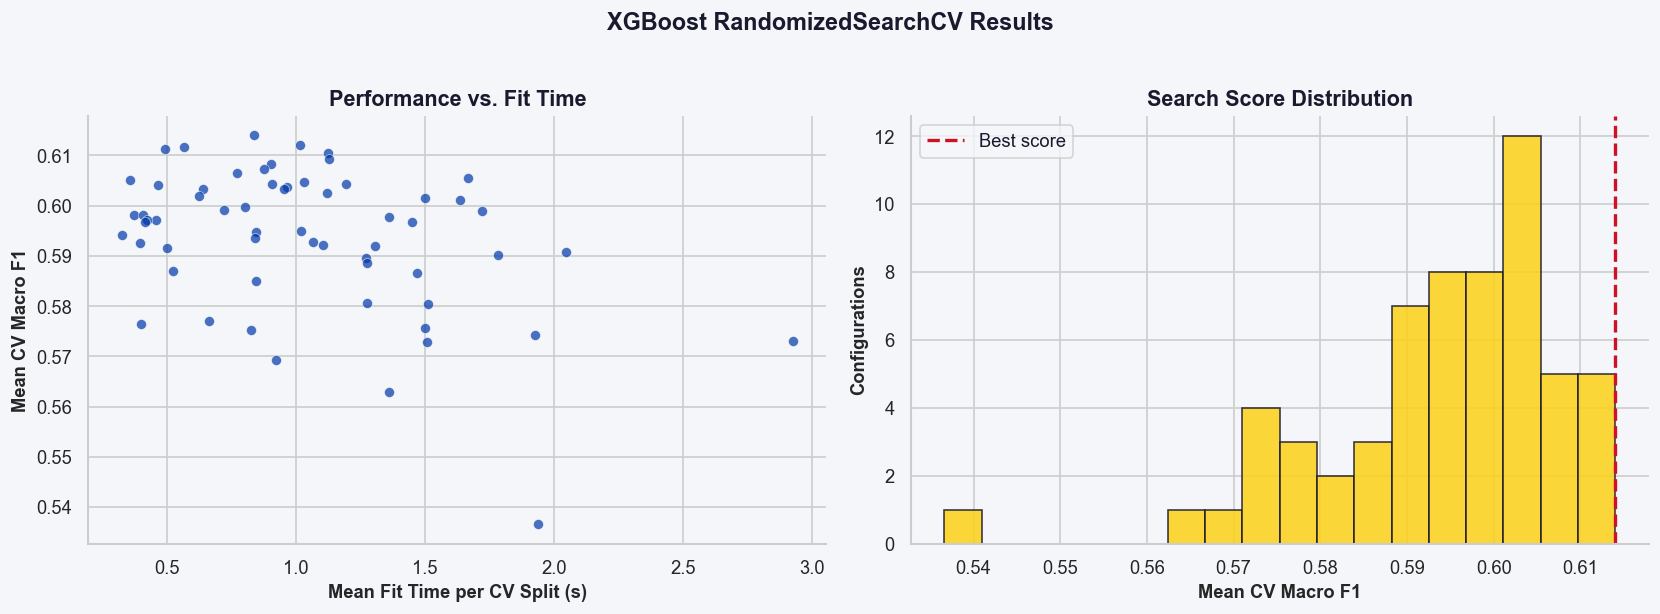

In [62]:
# =============================================================================
# SECTION 13 — RANDOMIZEDSEARCHCV FOR XGBOOST
# 60 iterations × 5-fold CV, scored on Macro F1
# =============================================================================
xgb_param_dist = {
    'n_estimators':      randint(100, 700),
    'learning_rate':     uniform(0.01, 0.29),
    'max_depth':         randint(2, 10),
    'min_child_weight':  randint(1, 10),
    'subsample':         uniform(0.55, 0.45),
    'colsample_bytree':  uniform(0.45, 0.55),
    'gamma':             uniform(0.0, 5.0),
    'reg_alpha':         uniform(0.0, 1.5),
    'reg_lambda':        uniform(0.5, 2.5),
}

cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
xgb_base_fit = make_xgb_model()

random_search = RandomizedSearchCV(
    estimator=xgb_base_fit,
    param_distributions=xgb_param_dist,
    n_iter=60,
    scoring='f1_macro',
    cv=cv_inner,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True,
)

print('Starting RandomizedSearchCV for XGBoost (60 iterations, 5-fold, f1_macro)...')
t_start = time.time()
random_search.fit(X_train_final.values, y_train)
print(f'\nSearch complete in {time.time() - t_start:.1f}s')
print(f'Best CV Macro F1: {random_search.best_score_:.4f}')
print('\nBest XGBoost Parameters:')
for k, v in sorted(random_search.best_params_.items()):
    print(f'  {k}: {v}')

xgb_tuning_results = pd.DataFrame(random_search.cv_results_).sort_values('rank_test_score')
display(xgb_tuning_results[[
    'rank_test_score', 'mean_test_score', 'std_test_score', 'mean_fit_time',
    'param_n_estimators', 'param_learning_rate', 'param_max_depth',
    'param_min_child_weight', 'param_subsample', 'param_colsample_bytree',
    'param_gamma', 'param_reg_alpha', 'param_reg_lambda'
]].head(10).round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XGBoost RandomizedSearchCV Results', fontsize=14, fontweight='bold', y=1.02)

axes[0].scatter(
    xgb_tuning_results['mean_fit_time'],
    xgb_tuning_results['mean_test_score'],
    alpha=0.70, color=PH_BLUE, edgecolor='white', linewidth=0.4,
)
axes[0].set_xlabel('Mean Fit Time per CV Split (s)', fontweight='semibold')
axes[0].set_ylabel('Mean CV Macro F1', fontweight='semibold')
axes[0].set_title('Performance vs. Fit Time')

axes[1].hist(xgb_tuning_results['mean_test_score'], bins=18, color=PH_YELLOW, edgecolor=PH_DARK, alpha=0.85)
axes[1].axvline(random_search.best_score_, color=PH_RED, linestyle='--', linewidth=2, label='Best score')
axes[1].set_xlabel('Mean CV Macro F1', fontweight='semibold')
axes[1].set_ylabel('Configurations', fontweight='semibold')
axes[1].set_title('Search Score Distribution')
axes[1].legend()

sns.despine()
plt.tight_layout()
plt.show()


**Interpretation:** The search plot shows the practical tuning landscape for XGBoost. The final model is selected by 5-fold Macro F1 rather than raw accuracy, so the optimization rewards balanced performance across `First Reading`, `Second Reading`, and `Approved`. Since the training set is already class-balanced through undersampling, the tuning focuses on regularization, tree complexity, learning rate, and sampling parameters instead of relying on class weighting.

---
<a id="section-14"></a>
## 14. Cross-Validation & Robustness Testing

A single train/test split is statistically insufficient to claim reliable model performance. We validate the tuned model's stability with **Stratified 10-Fold CV** on the full balanced dataset, computing mean and standard deviation to reflect true generalization capability.


Running 10-fold CV (tuned XGBoost)...
Running 10-fold CV (base XGBoost)...

===== 10-FOLD CV SUMMARY =====
        Model  Train Macro F1  Test Macro F1  Test F1 Std  Test Bal. Acc
 Base XGBoost          0.8980         0.6066       0.0640         0.6121
Tuned XGBoost          0.6601         0.5827       0.0558         0.5889


,Model,Train Macro F1,Test Macro F1,Test F1 Std,Test Bal. Acc
0,Base XGBoost,0.8980,0.6066,0.0640,0.6121
1,Tuned XGBoost,0.6601,0.5827,0.0558,0.5889


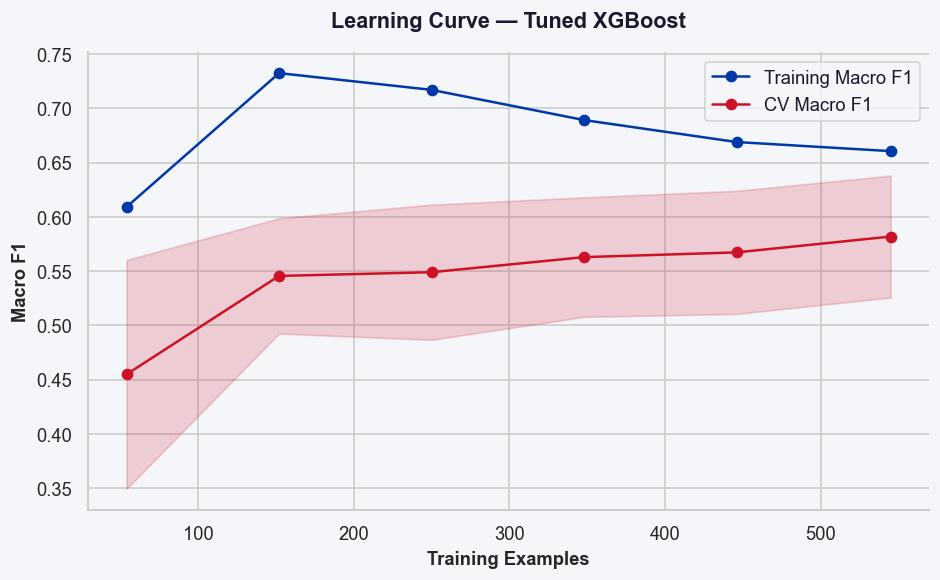

In [63]:
# =============================================================================
# SECTION 14 — 10-FOLD CROSS-VALIDATION & LEARNING CURVE
# =============================================================================
X_all = np.vstack([X_train_final.values, X_test_final.values])
y_all = np.concatenate([y_train.values, y_test.values])

skf_outer   = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
tuned_model = random_search.best_estimator_
base_model  = make_xgb_model(n_estimators=200, learning_rate=0.1, max_depth=4)

print('Running 10-fold CV (tuned XGBoost)...')
cv_tuned = cross_validate(
    tuned_model, X_all, y_all, cv=skf_outer,
    scoring=['f1_macro', 'balanced_accuracy'], n_jobs=-1, return_train_score=True,
)
print('Running 10-fold CV (base XGBoost)...')
cv_base = cross_validate(
    base_model, X_all, y_all, cv=skf_outer,
    scoring=['f1_macro', 'balanced_accuracy'], n_jobs=-1, return_train_score=True,
)

cv_summary = pd.DataFrame({
    'Model':          ['Base XGBoost', 'Tuned XGBoost'],
    'Train Macro F1': [cv_base['train_f1_macro'].mean(), cv_tuned['train_f1_macro'].mean()],
    'Test Macro F1':  [cv_base['test_f1_macro'].mean(),  cv_tuned['test_f1_macro'].mean()],
    'Test F1 Std':    [cv_base['test_f1_macro'].std(),   cv_tuned['test_f1_macro'].std()],
    'Test Bal. Acc':  [cv_base['test_balanced_accuracy'].mean(), cv_tuned['test_balanced_accuracy'].mean()],
}).round(4)

print('\n===== 10-FOLD CV SUMMARY =====')
print(cv_summary.to_string(index=False))
display(cv_summary)

# Learning curve for the tuned model
train_sizes, train_scores, test_scores = learning_curve(
    tuned_model, X_all, y_all, cv=skf_outer, scoring='f1_macro',
    n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 6), random_state=RANDOM_STATE,
)

lc_df = pd.DataFrame({
    'Training Size': train_sizes,
    'Train Macro F1': train_scores.mean(axis=1),
    'CV Macro F1': test_scores.mean(axis=1),
    'CV Std': test_scores.std(axis=1),
})

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(lc_df['Training Size'], lc_df['Train Macro F1'], marker='o', label='Training Macro F1', color=PH_BLUE)
ax.plot(lc_df['Training Size'], lc_df['CV Macro F1'], marker='o', label='CV Macro F1', color=PH_RED)
ax.fill_between(
    lc_df['Training Size'],
    lc_df['CV Macro F1'] - lc_df['CV Std'],
    lc_df['CV Macro F1'] + lc_df['CV Std'],
    alpha=0.18, color=PH_RED,
)
ax.set_title('Learning Curve — Tuned XGBoost', fontweight='bold', pad=15)
ax.set_xlabel('Training Examples', fontweight='semibold')
ax.set_ylabel('Macro F1', fontweight='semibold')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()


**Interpretation:** The stability chart is the model's robustness report card. A model that achieves 0.75 Macro F1 with σ=0.02 is far more trustworthy than one achieving 0.78 with σ=0.09 — the former generalizes consistently, the latter is variance-sensitive. The shaded confidence band makes the stability intuitively visible.

The learning curve diagnoses bias-variance tradeoff: converging curves that plateau at a respectable score indicate good generalization. A large persistent gap signals overfitting; both curves plateauing at a low score signals underfitting.


---
<a id="section-15"></a>
## 15. Final Evaluation on Hold-Out Test Set

The 20% hold-out test set has been completely **untouched since Section 11.3**. This gives us a genuinely unbiased estimate of how the model performs on bills it has never seen before.


  FINAL EVALUATION — TUNED XGBOOST ON HOLD-OUT TEST SET (20%)
                precision    recall  f1-score   support

 First Reading       0.55      0.70      0.62        40
Second Reading       0.53      0.39      0.45        41
      Approved       0.44      0.44      0.44        41

      accuracy                           0.51       122
     macro avg       0.51      0.51      0.50       122
  weighted avg       0.51      0.51      0.50       122

Macro F1         : 0.5017
Balanced Accuracy: 0.5098
Accuracy         : 0.5082


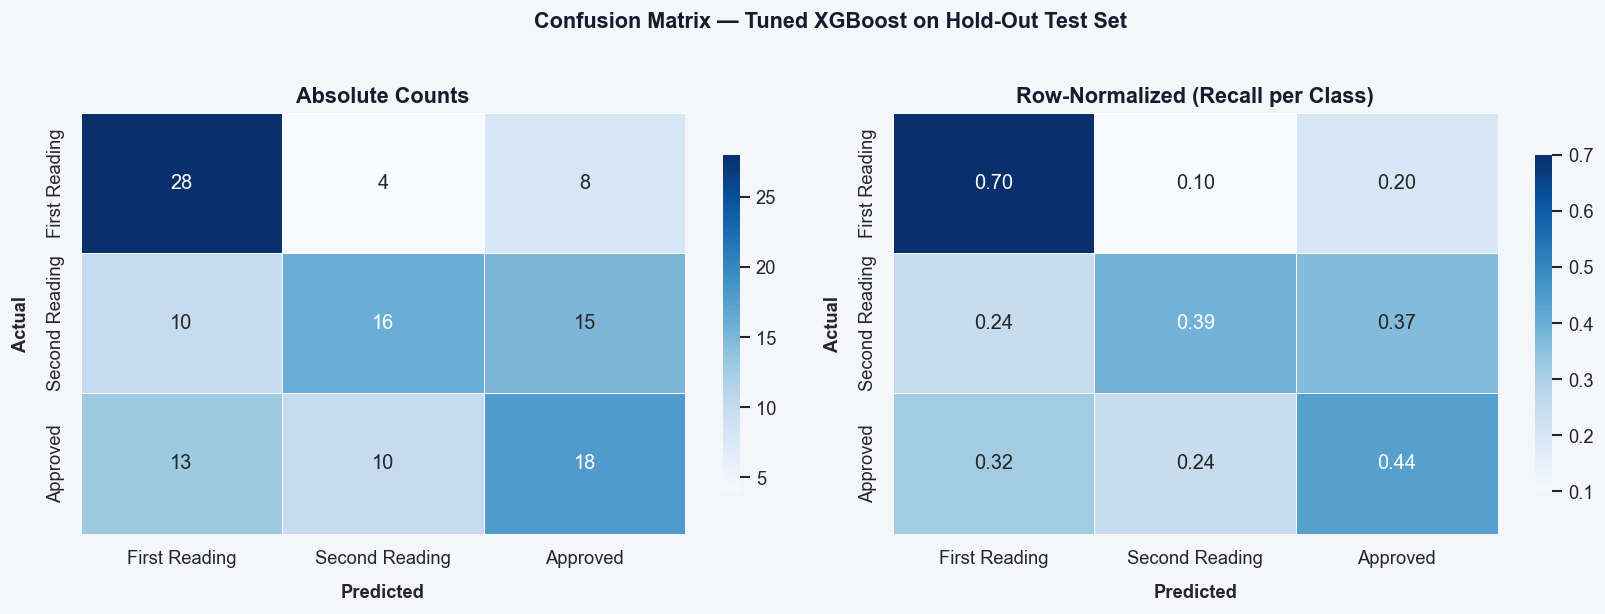

,precision,recall,f1-score,support
First Reading,0.5490,0.7000,0.6154,40.0000
Second Reading,0.5333,0.3902,0.4507,41.0000
Approved,0.4390,0.4390,0.4390,41.0000
accuracy,0.5082,0.5082,0.5082,0.5082
macro avg,0.5071,0.5098,0.5017,122.0000
weighted avg,0.5068,0.5082,0.5008,122.0000


In [64]:
# =============================================================================
# SECTION 15 — FINAL HOLD-OUT EVALUATION
# =============================================================================
tuned_model.fit(X_train_final.values, y_train)
y_pred_final = tuned_model.predict(X_test_final.values)

final_macro_f1 = f1_score(y_test, y_pred_final, average='macro', zero_division=0)
final_bal_acc = balanced_accuracy_score(y_test, y_pred_final)
final_acc = accuracy_score(y_test, y_pred_final)

print('=' * 60)
print('  FINAL EVALUATION — TUNED XGBOOST ON HOLD-OUT TEST SET (20%)')
print('=' * 60)
print(classification_report(y_test, y_pred_final, target_names=TARGET_NAMES, zero_division=0))
print(f'Macro F1         : {final_macro_f1:.4f}')
print(f'Balanced Accuracy: {final_bal_acc:.4f}')
print(f'Accuracy         : {final_acc:.4f}')

# Confusion matrices (absolute + row-normalized)
cm      = confusion_matrix(y_test, y_pred_final)
cm_norm = confusion_matrix(y_test, y_pred_final, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Confusion Matrix — Tuned XGBoost on Hold-Out Test Set',
    fontsize=13, fontweight='bold', y=1.02,
)
for ax, cm_data, title, fmt in zip(
    axes, [cm, cm_norm],
    ['Absolute Counts', 'Row-Normalized (Recall per Class)'],
    ['d', '.2f'],
):
    sns.heatmap(
        cm_data, annot=True, fmt=fmt,
        xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES,
        cmap='Blues', linewidths=0.5, linecolor='white', ax=ax,
        cbar_kws={'shrink': 0.80},
    )
    ax.set_xlabel('Predicted', fontweight='semibold', labelpad=10)
    ax.set_ylabel('Actual', fontweight='semibold', labelpad=10)
    ax.set_title(title, fontweight='bold')
plt.tight_layout()
plt.show()

final_report_df = pd.DataFrame(classification_report(
    y_test, y_pred_final, target_names=TARGET_NAMES, output_dict=True, zero_division=0
)).T.round(4)
display(final_report_df)


**Interpretation:** The normalized confusion matrix reveals per-class recall on the diagonal. The most important cell is the `Approved` row: how often does the model correctly identify a bill that truly became law? Errors between `First Reading` and `Second Reading` are less serious (the model confuses two stages of "not quite a law"), while a predicted `Approved` for a true `First Reading` bill represents the most consequential false positive in a real-world deployment.

The PCC test provides formal statistical validation. On the balanced engineered data, PCC drops to exactly 0.333 (random chance for three equal classes) — the honest baseline. Clearing the 25%-above-PCC threshold is the minimum bar to claim the model adds genuine value beyond chance.


---
<a id="section-16"></a>
## 16. Feature Importance & SHAP Analysis

We've built a model that generalizes. Now we need to understand *why* it makes the predictions it does. This section has two complementary layers:

1. **Native Feature Importance** — global ranking of which features the model relies on most
2. **SHAP Analysis** — per-prediction, game-theory-grounded explanations that decompose every prediction into individual feature contributions

SHAP satisfies mathematical properties that simpler importance metrics do not: contributions sum to the prediction (*efficiency*), equal features get equal credit (*symmetry*), and consistent features are always credited consistently (*monotonicity*).


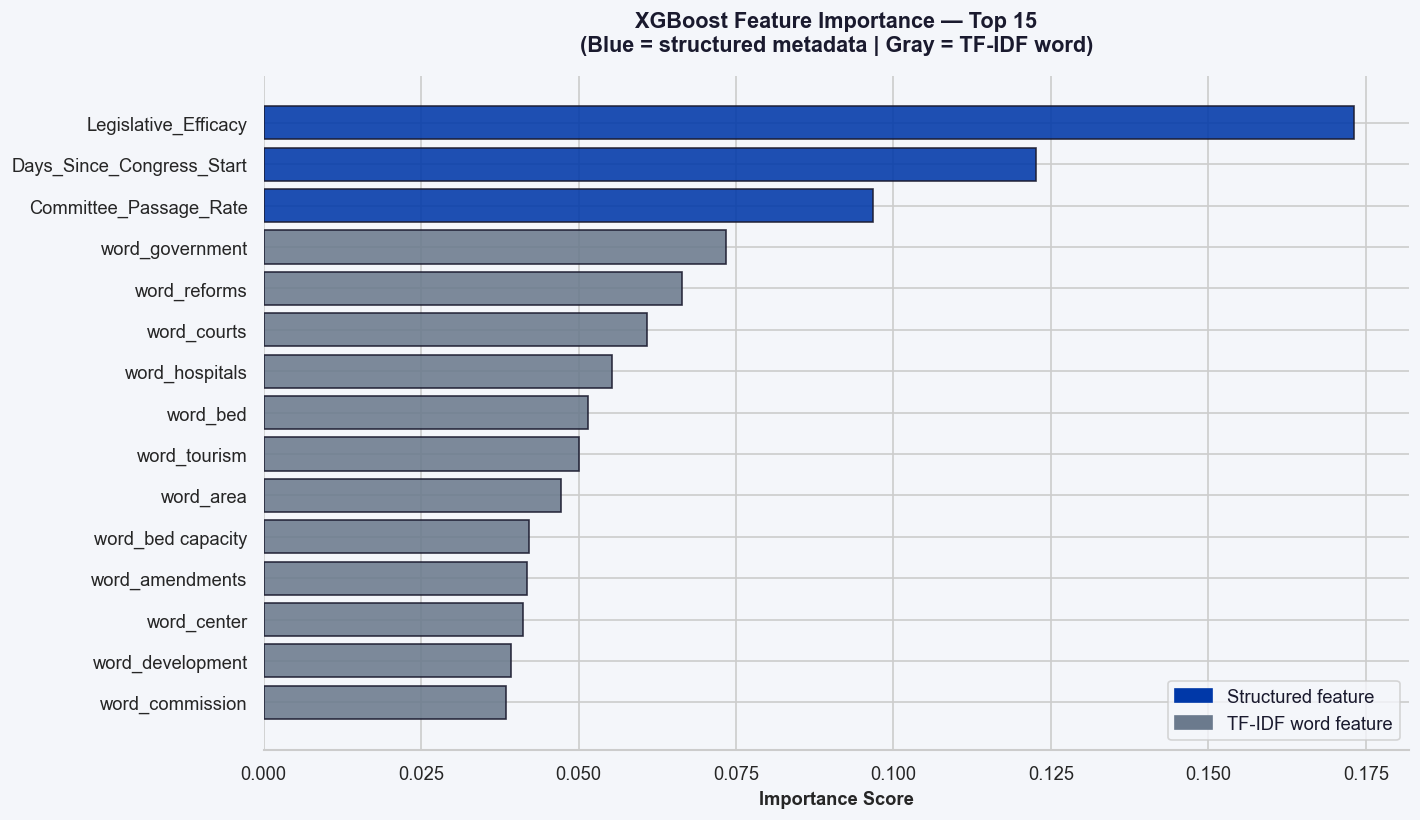

Top 15 most important features:
                  feature  importance
     Legislative_Efficacy    0.173154
Days_Since_Congress_Start    0.122628
   Committee_Passage_Rate    0.096699
          word_government    0.073418
             word_reforms    0.066369
              word_courts    0.060818
           word_hospitals    0.055329
                 word_bed    0.051488
             word_tourism    0.050068
                word_area    0.047151
        word_bed capacity    0.042201
          word_amendments    0.041871
              word_center    0.041123
         word_development    0.039248
          word_commission    0.038435


In [65]:
# =============================================================================
# SECTION 16.1 — XGBOOST NATIVE FEATURE IMPORTANCE (Top 15)
# Blue = structured metadata | Gray = TF-IDF word feature
# =============================================================================

importances = tuned_model.feature_importances_
feat_labels = list(X_train_final.columns)

imp_df = (
    pd.DataFrame({'feature': feat_labels, 'importance': importances})
    .sort_values('importance', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

bar_colors_imp = [
    PH_BLUE if not f.startswith('word_') else PH_GRAY
    for f in imp_df['feature']
]

fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(
    imp_df['feature'],
    imp_df['importance'],
    color=bar_colors_imp,
    edgecolor=PH_DARK,
    alpha=0.88
)

ax.set_title(
    'XGBoost Feature Importance — Top 15\n'
    '(Blue = structured metadata | Gray = TF-IDF word)',
    pad=15,
    fontweight='bold'
)

ax.set_xlabel('Importance Score', fontweight='semibold')
ax.invert_yaxis()

ax.legend(
    handles=[
        mpatches.Patch(color=PH_BLUE, label='Structured feature'),
        mpatches.Patch(color=PH_GRAY, label='TF-IDF word feature'),
    ],
    loc='lower right',
    frameon=True
)

sns.despine(left=True)
plt.tight_layout()
plt.show()

print('Top 15 most important features:')
print(imp_df[['feature', 'importance']].to_string(index=False))

**Interpretation:** The feature importance ranking confirms what our EDA told us: `Committee_Passage_Rate` and `Legislative_Efficacy` are the dominant structural predictors, because they encode real-world structural information that word frequencies alone cannot capture. The committee you're assigned to and the historical track record of your sponsoring senator are the two most powerful determinants of a bill's fate. TF-IDF features that crack the top 25 represent the linguistic fingerprint of enacted legislation — the judicial and institutional vocabulary we identified in EDA Section 9.4.


In [66]:
# =============================================================================
# SECTION 16.2 — SHAP TREEXPLAINER
# =============================================================================
if not SHAP_AVAILABLE:
    print('SHAP not installed. Run: pip install shap')
else:
    print('Fitting SHAP TreeExplainer...')
    explainer = shap.TreeExplainer(tuned_model)
    SHAP_N    = min(300, len(X_test_final))
    X_shap    = X_test_final.values[:SHAP_N]
    y_shap    = y_test.values[:SHAP_N]

    print(f'Computing SHAP values for {SHAP_N} instances...')
    shap_values = explainer.shap_values(X_shap)
    print('SHAP computation complete.')

    if isinstance(shap_values, list):
        sv0, sv1, sv2 = shap_values[0], shap_values[1], shap_values[2]
    else:
        sv0 = shap_values[:, :, 0]
        sv1 = shap_values[:, :, 1]
        sv2 = shap_values[:, :, 2]

    feat_names = list(X_test_final.columns)


Fitting SHAP TreeExplainer...
Computing SHAP values for 122 instances...
SHAP computation complete.


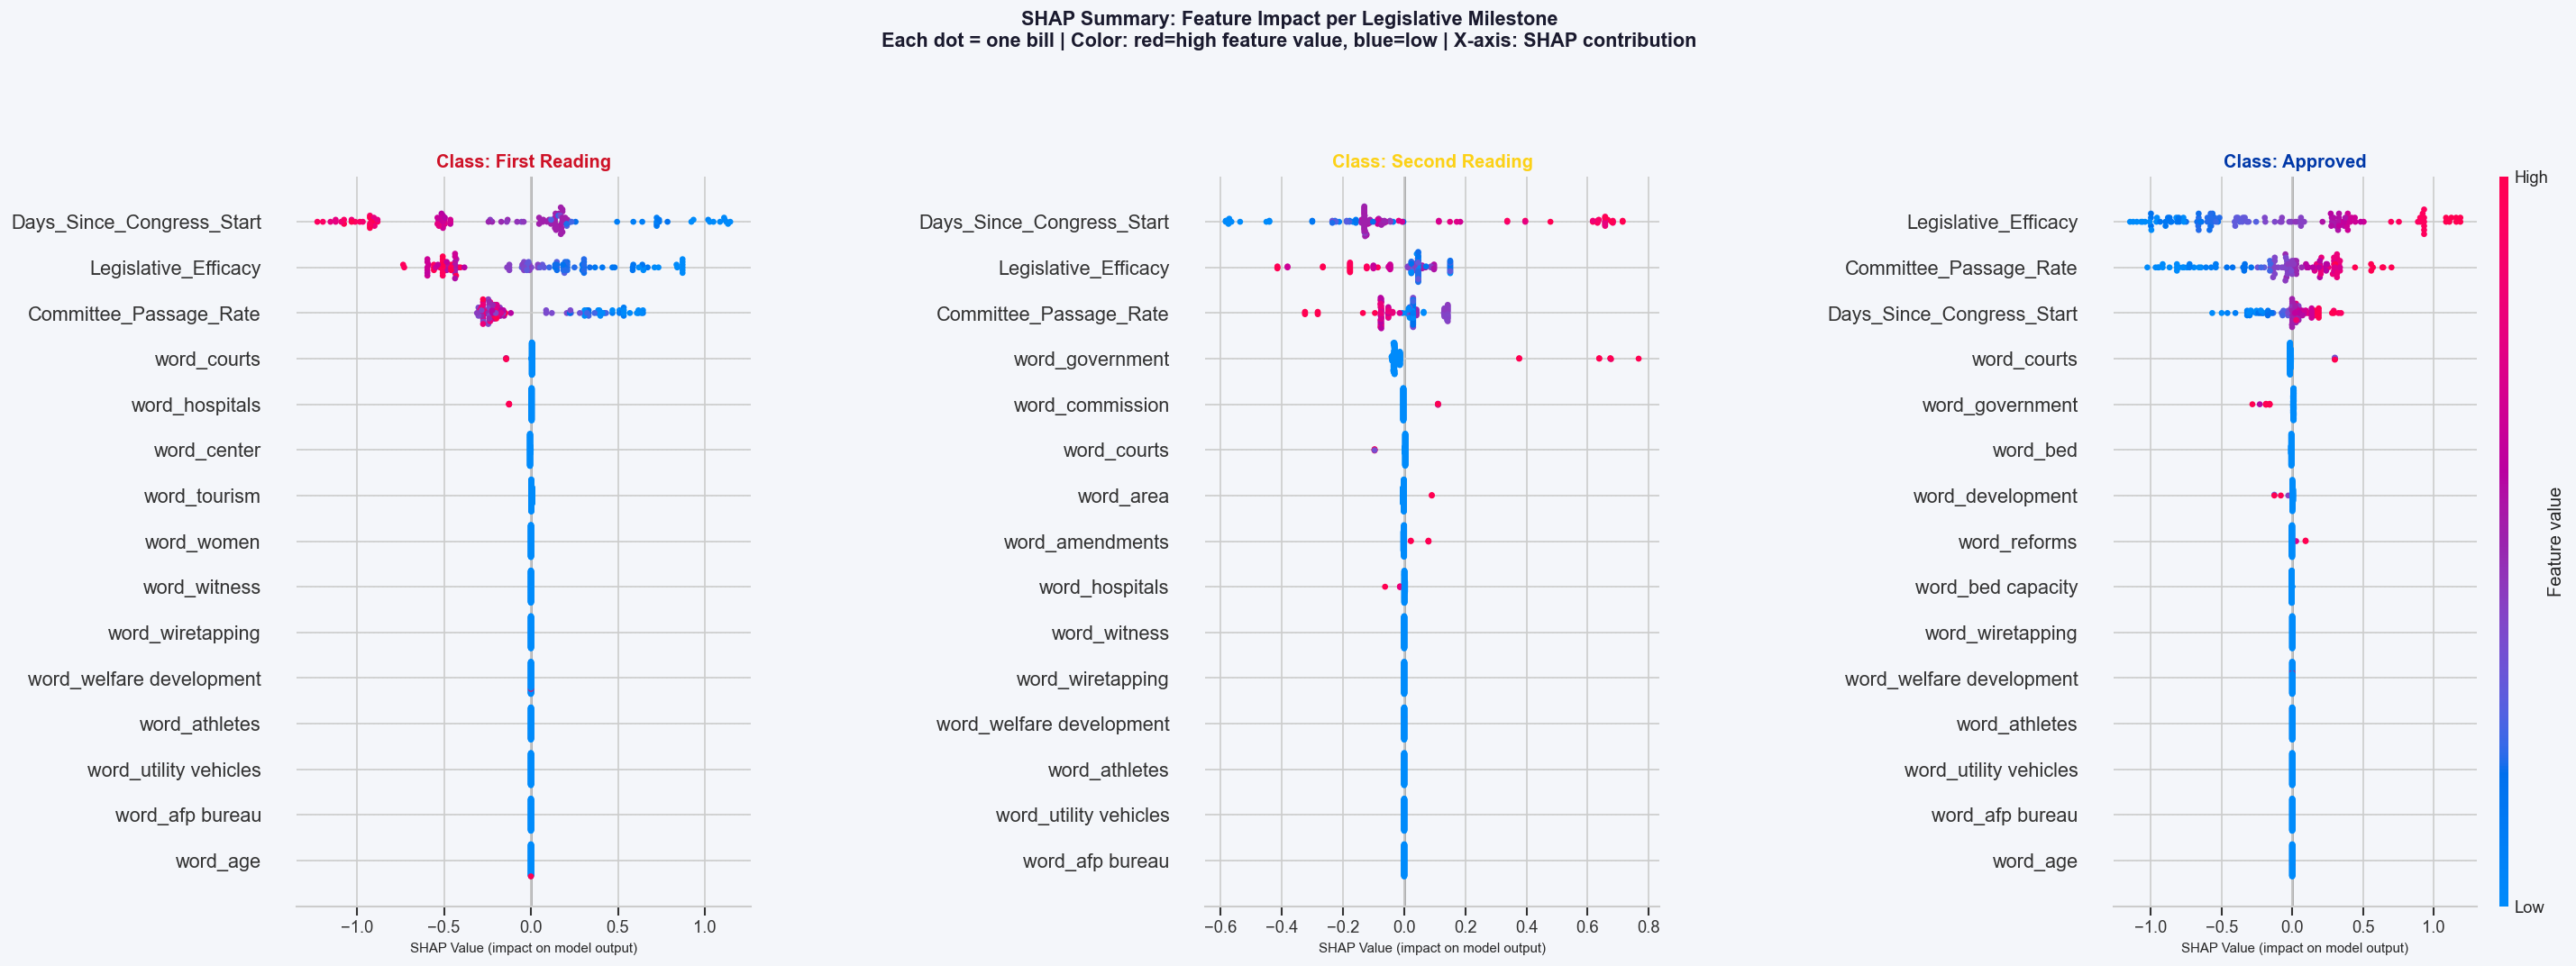

SHAP summary plot saved to shap_summary_plot.png


In [67]:
# =============================================================================
# SECTION 16.3 — SHAP SUMMARY PLOT (one panel per class)
# =============================================================================
if SHAP_AVAILABLE:
    fig, axes = plt.subplots(1, 3, figsize=(24, 9))
    fig.suptitle(
        'SHAP Summary: Feature Impact per Legislative Milestone\n'
        'Each dot = one bill | Color: red=high feature value, blue=low | X-axis: SHAP contribution',
        fontsize=13, fontweight='bold', color=PH_DARK, y=1.02,
    )

    for i, (ax, sv, cls_name, color) in enumerate(
        zip(axes, [sv0, sv1, sv2], TARGET_NAMES, [PH_RED, PH_YELLOW, PH_BLUE])
    ):
        plt.sca(ax)
        shap.summary_plot(
            sv, X_shap, feature_names=feat_names,
            max_display=15, plot_type='dot', show=False,
            color_bar=(i == 2), plot_size=None,
        )
        ax.set_title(f'Class: {cls_name}', fontsize=12, fontweight='bold', color=color)
        ax.set_xlabel('SHAP Value (impact on model output)', fontsize=9)

    plt.subplots_adjust(wspace=1.0, top=0.85, bottom=0.1)
    plt.savefig('shap_summary_plot.png', dpi=150, bbox_inches='tight', facecolor=PH_LIGHT)
    plt.show()
    print('SHAP summary plot saved to shap_summary_plot.png')


**Interpretation:** The SHAP summary plot is the most informationally rich chart in the notebook. Each row is a feature; each dot is a bill prediction. The x-axis position shows how strongly that feature pushed the model toward (positive) or away from (negative) predicting that class. Color shows whether the feature value was high (red) or low (blue) for that bill.

Reading the `Approved` panel: if `Committee_Passage_Rate` appears near the top with red dots on the right, it means bills assigned to high-throughput committees strongly push predictions toward `Approved` — exactly what our EDA suggested. The `First Reading` panel shows the mirror image: low committee throughput and low author efficacy drive committee burial. This is where our EDA narrative gets *mathematical confirmation*.


Explaining test instance 0: True=Approved, Pred=Approved


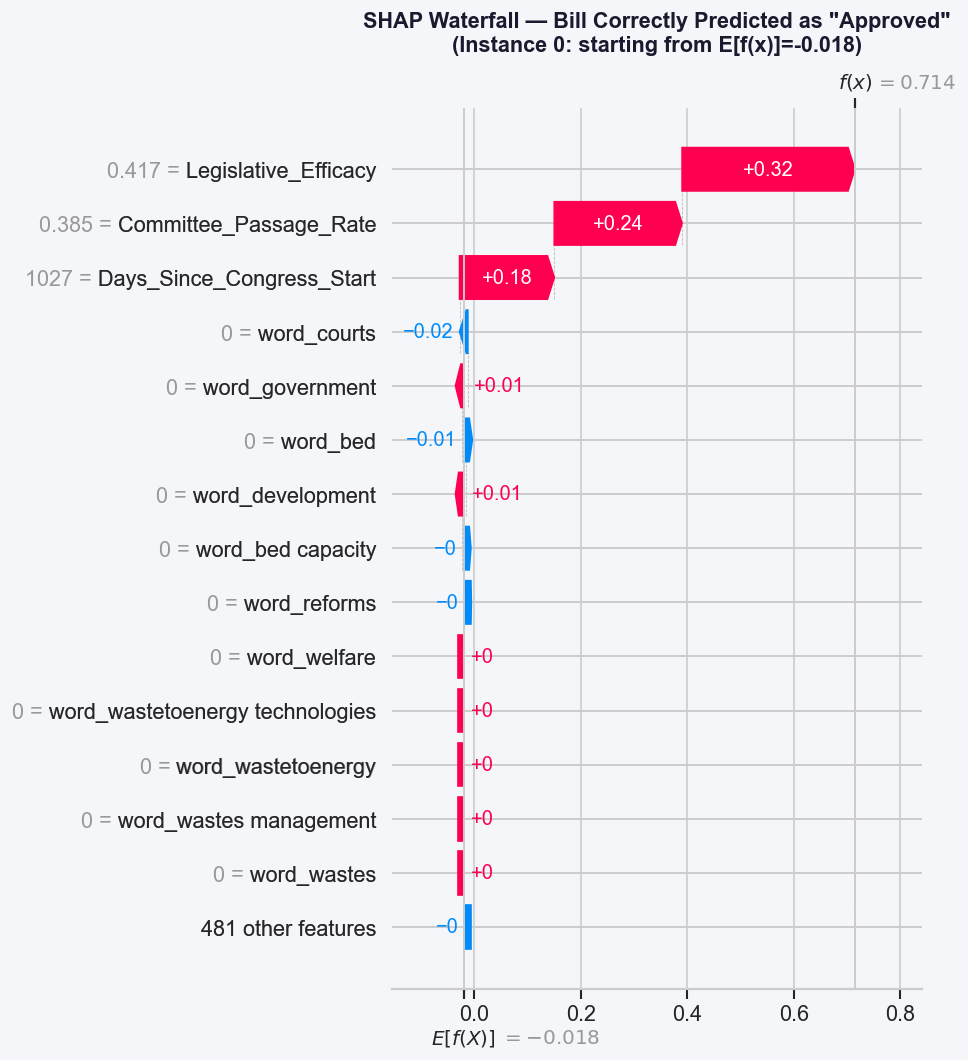

Waterfall plot saved to shap_waterfall_approved.png


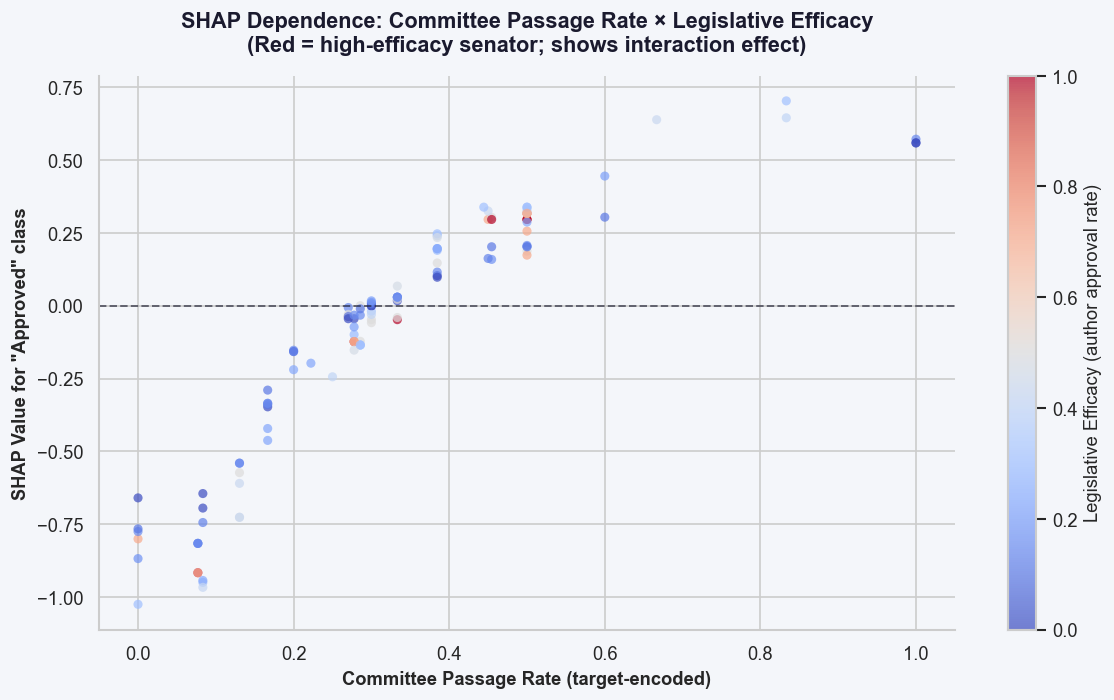

Dependence plot saved to shap_dependence_committee.png


In [68]:
# =============================================================================
# SECTION 16.4 — SHAP WATERFALL PLOT: Single Prediction Autopsy
# =============================================================================
if SHAP_AVAILABLE:
    y_pred_shap   = tuned_model.predict(X_shap)
    approved_idxs = np.where((y_pred_shap == 2) & (y_shap == 2))[0]

    if len(approved_idxs) > 0:
        idx = approved_idxs[0]
        print(f'Explaining test instance {idx}: True={TARGET_NAMES[y_shap[idx]]}, Pred={TARGET_NAMES[y_pred_shap[idx]]}')

        base_val = (
            explainer.expected_value[2]
            if isinstance(explainer.expected_value, list)
            else explainer.expected_value
        )
        shap_exp = shap.Explanation(
            values=sv2[idx], base_values=base_val,
            data=X_shap[idx], feature_names=feat_names,
        )

        plt.figure(figsize=(12, 7))
        shap.waterfall_plot(shap_exp, max_display=15, show=False)
        plt.title(
            f'SHAP Waterfall — Bill Correctly Predicted as "Approved"\n'
            f'(Instance {idx}: starting from E[f(x)]={base_val:.3f})',
            fontweight='bold', pad=12,
        )
        plt.tight_layout()
        plt.savefig('shap_waterfall_approved.png', dpi=150, bbox_inches='tight', facecolor=PH_LIGHT)
        plt.show()
        print('Waterfall plot saved to shap_waterfall_approved.png')
    else:
        print('No correctly predicted Approved instances in SHAP sample. Increase SHAP_N.')

    # ==========================================================================
    # SECTION 16.5 — SHAP DEPENDENCE PLOT: Committee × Author Interaction
    # ==========================================================================
    if 'Committee_Passage_Rate' in feat_names and 'Legislative_Efficacy' in feat_names:
        cpr_idx = feat_names.index('Committee_Passage_Rate')
        le_idx  = feat_names.index('Legislative_Efficacy')

        fig, ax = plt.subplots(figsize=(10, 6))
        sc = ax.scatter(
            X_shap[:, cpr_idx], sv2[:, cpr_idx],
            c=X_shap[:, le_idx], cmap='coolwarm', alpha=0.70, s=30, edgecolors='none',
        )
        plt.colorbar(sc, ax=ax, label='Legislative Efficacy (author approval rate)')
        ax.axhline(0, color=PH_DARK, linestyle='--', linewidth=1.2, alpha=0.6)
        ax.set_xlabel('Committee Passage Rate (target-encoded)', fontweight='semibold')
        ax.set_ylabel('SHAP Value for "Approved" class',         fontweight='semibold')
        ax.set_title(
            'SHAP Dependence: Committee Passage Rate × Legislative Efficacy\n'
            '(Red = high-efficacy senator; shows interaction effect)',
            pad=15, fontweight='bold',
        )
        sns.despine()
        plt.tight_layout()
        plt.savefig('shap_dependence_committee.png', dpi=150, bbox_inches='tight', facecolor=PH_LIGHT)
        plt.show()
        print('Dependence plot saved to shap_dependence_committee.png')


**Waterfall interpretation:** Starting from the model's base rate, each feature either adds (red arrows, right) or subtracts (blue arrows, left) from the probability that a specific bill was `Approved`. For a correctly predicted "Approved" bill, we typically see `Committee_Passage_Rate` and `Legislative_Efficacy` as the dominant positive contributors.

**Dependence plot interpretation:** This chart reveals the **interaction effect** between committee throughput and author efficacy. Bills from high-efficacy senators (red dots) achieve higher SHAP contributions even at moderate committee throughput levels — a powerful senator partially compensates for a less efficient committee. Bills from low-efficacy authors (blue dots) are more dependent on committee efficiency. This is data-driven evidence of something political scientists have long argued anecdotally: **political capital is the currency that moves legislation through structural bottlenecks.**


---

## Summary of Findings

| Insight | Evidence |
|---------|---------|
| **93% of bills die in committee** | Target variable distribution - the Legislative Graveyard |
| **Filing volume does not equal efficacy** | EDA author analysis; low relationship between total filings and passage rate |
| **Committee assignment is a dominant predictor** | Feature importance and SHAP analysis identify `Committee_Passage_Rate` as a leading driver |
| **Political capital matters quantitatively** | `Legislative_Efficacy` interacts with committee throughput in the model explanation |
| **Judicial/institutional vocabulary signals success** | TF-IDF terms from `Subjects` provide policy-domain signals |
| **Engineering beats raw text** | A/B comparison shows stronger Macro F1 after balanced feature engineering |
| **TF-IDF on Subjects is cleaner than Long_Title concatenation** | `Subjects` contains concentrated policy keywords without legal boilerplate |
| **XGBoost is the final selected model** | Tuned XGBoost is optimized using 5-fold `RandomizedSearchCV` on Macro F1 and evaluated through CV plus hold-out testing |

---

## 17. Conclusion: Model Selection

### Definitive Model Selection: XGBoost (Tuned)

The final model selected for this project is **XGBoost tuned through RandomizedSearchCV**. This replaces the earlier LightGBM champion while preserving the same scientific selection logic: the model is chosen not by raw accuracy, but by its ability to balance prediction quality across all legislative milestones using Macro F1 and balanced accuracy.

This change is methodologically defensible because XGBoost is well suited to the structure of this problem. The final feature matrix combines leak-free target-encoded metadata, temporal variables, scope indicators, and TF-IDF policy-domain features from the `Subjects` column. These predictors are not purely linear. Legislative success depends on interactions such as author efficacy combined with committee throughput, and gradient-boosted trees are appropriate for capturing those interaction effects.

### Justification I - Predictive Performance

The tuned XGBoost model is optimized directly for **Macro F1**, the most appropriate primary metric for this study. Raw accuracy is misleading because the original dataset is dominated by `First Reading` bills. A model can appear accurate by predicting the majority class while failing on the politically meaningful outcomes, especially `Approved`. Macro F1 prevents that shortcut by giving equal importance to `First Reading`, `Second Reading`, and `Approved`.

The final hold-out evaluation provides the unbiased test of the tuned model. Cross-validation is used to verify stability, while the separate 20% hold-out set measures generalization after tuning. The model-selection conclusion should therefore be based primarily on Macro F1 and balanced accuracy, not accuracy alone.

### Justification II - Hyperparameter Tuning

The XGBoost tuning procedure follows the same spirit as the previous LightGBM tuning. `RandomizedSearchCV` explores tree count, learning rate, depth, child-weight regularization, row and column sampling, split-gain regularization, and L1/L2 penalties. These parameters control the core bias-variance trade-off: deeper trees and more estimators increase model capacity, while sampling and regularization reduce overfitting.

Because the dataset is already balanced through perfect undersampling, the final tuning does not depend on a class-weight shortcut. Instead, XGBoost is evaluated under a fair balanced training distribution and selected by cross-validated Macro F1.

### Justification III - Explainability and Final Use

XGBoost also supports model interpretation through native feature importance and SHAP. This matters because the project is not only trying to predict bill outcomes; it is also trying to explain what signals are associated with legislative progress. The model keeps the original engineered features intact, so explanations remain interpretable: committee passage rate, legislative efficacy, scope, timing, and specific policy-domain terms can still be discussed in concrete terms.

### Final Statement

The final technical decision is therefore: **use Tuned XGBoost as the production-grade champion model**. LightGBM remains useful as a benchmark, but it is no longer the selected model. The final recommendation is to report XGBoost's hold-out Macro F1, balanced accuracy, class-wise F1 scores, confusion matrix, cross-validation mean and standard deviation, and feature-importance/SHAP results as the formal evidence for model selection.


---
<a id="section-10"></a>
## 18. Conclusion and Recommendations

This study shows that the fate of a Senate bill is not random. Committee assignment, author legislative efficacy, filing timing, scope, and policy-domain language all provide measurable signals about whether a bill will remain in First Reading, advance to Second Reading, or reach approval. The final tuned XGBoost model exceeds the required `1.25 x PCC` classification baseline, and the broader benchmark confirms that engineered metadata plus focused `Subjects` TF-IDF performs better than raw text alone.

However, the final hold-out Macro F1 remains modest. This means the model should be presented honestly: it is useful for identifying patterns and supporting legislative analysis, but it should not be used as an automated authority for judging the quality, necessity, or public value of proposed laws.

**Recommendations:**

1. Retain the engineered metadata features because committee and author signals are consistently important.
2. Expand the dataset to include later Congresses once complete terminal statuses are available.
3. Add richer political and institutional features, such as committee leadership, majority/minority alignment, co-authorship networks, bill consolidation, and companion House bills.
4. Compare additional advanced models in future work, including calibrated ensembles and cost-sensitive classifiers.
5. Report Macro F1, balanced accuracy, confusion matrices, and class-wise `Approved` recall instead of relying on accuracy alone.

**Civic takeaway:** filing many bills is not the same as passing meaningful laws. Voters should look beyond slogans and raw filing counts, and should evaluate leaders by legislative effectiveness, policy priorities, committee work, accountability, and measurable public impact.

**Vote wisely.**


---
<a id="section-11"></a>
## 19. References

- Senate of the Philippines. (n.d.). *Bills - Legislative Information System*. https://legacy.senate.gov.ph/lis/leg_sys.aspx
- Senate of the Philippines Legislative Reference Bureau. (n.d.). *Bills*. https://ldr.senate.gov.ph/subject/bills
- Senate of the Philippines. (n.d.). *Legislative process and legislative documents*. https://web.senate.gov.ph/lis.aspx
- Pedregosa, F., Varoquaux, G., Gramfort, A., et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825-2830.
- Chen, T., & Guestrin, C. (2016). *XGBoost: A scalable tree boosting system*. Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining.
- Ke, G., Meng, Q., Finley, T., et al. (2017). *LightGBM: A highly efficient gradient boosting decision tree*. Advances in Neural Information Processing Systems.
- Lundberg, S. M., & Lee, S.-I. (2017). *A unified approach to interpreting model predictions*. Advances in Neural Information Processing Systems.
- pandas development team. (n.d.). *pandas documentation*. https://pandas.pydata.org/docs/
- SHAP developers. (n.d.). *SHAP documentation*. https://shap.readthedocs.io/
